```
---
title: Black list of small molecules in BioPAX
tags: BioPAX, smallMolecules, SPARQL, Reactome, ChEBI, blacklist, Homo_sapiens
lang: en
version: 0.17
date: 2026-08-05
---
```

In [1]:
import collections
#import importlib
import IPython
#import json
import matplotlib.pyplot as plt
#import networkx as nx
import numpy as np
#import os
import pandas
import plotly.express as px
#import rdflib
#import rdflib.namespace
import scipy.stats as stats
import sparqldataframe
from SPARQLWrapper import SPARQLWrapper, JSON
# import statsmodels.stats.multitest
#import sys

In [6]:
reactomeVersion = 96 # 2026-03-25
#reactomeVersion = 97 # 2026-06-21
#chebiVersion = 252 # CHECKED BY QUERY BELOW
#endpointURL = "http://localhost:3030/reactome/query"
#endpointURL = "http://localhost:3030/chebi/query"
endpointURL = "http://localhost:3030/reactomeChEBI/query"
rdfFormat = "turtle"

In [3]:
prefixes = """
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs:<http://www.w3.org/2000/01/rdf-schema#>
PREFIX owl: <http://www.w3.org/2002/07/owl#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
PREFIX dc: <http://purl.org/dc/elements/1.1/>
PREFIX dcterms: <http://purl.org/dc/terms/>

PREFIX CHEBI: <http://purl.obolibrary.org/obo/CHEBI_>
PREFIX chebirel: <http://purl.obolibrary.org/obo/CHEBI#>
PREFIX oboInOwl: <http://www.geneontology.org/formats/oboInOwl#>

PREFIX bp3: <http://www.biopax.org/release/biopax-level3.owl#>

PREFIX reactome: <http://www.reactome.org/biopax/{}/48887#>
""".format(reactomeVersion)

In [4]:
query="""
PREFIX rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX rdfs:<http://www.w3.org/2000/01/rdf-schema#>
PREFIX owl: <http://www.w3.org/2002/07/owl#>
PREFIX xsd: <http://www.w3.org/2001/XMLSchema#>
PREFIX dc: <http://purl.org/dc/elements/1.1/>
PREFIX dcterms: <http://purl.org/dc/terms/>

SELECT ?ontology ?versionIRI (REPLACE(REPLACE(STR(?versionIRI), 'http://purl.obolibrary.org/obo/chebi/', ''), '/chebi.owl', '') AS ?versionNumber)
WHERE {
  ?ontology rdf:type owl:Ontology .
  ?ontology owl:versionIRI ?versionIRI .
}
"""

sparql = SPARQLWrapper(endpointURL)
sparql.setQuery(prefixes+query)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

chebiVersion = int(results["results"]["bindings"][0]["versionNumber"]["value"])
print("ChEBI version: {}".format(chebiVersion))

ChEBI version: 252


In [5]:
def displaySparqlResults(results):
    '''
    Displays as HTML the result of a SPARQLWrapper query in a Jupyter notebook.
    
        Parameters:
            results (dictionnary): the result of a call to SPARQLWrapper.query().convert()
    '''
    variableNames = results['head']['vars']
    tableCode = '<table><tr><th>{}</th></tr><tr>{}</tr></table>'.format('</th><th>'.join(variableNames), '</tr><tr>'.join('<td>{}</td>'.format('</td><td>'.join([row[vName]['value'] if vName in row.keys() else "&nbsp;" for vName in variableNames]))for row in results["results"]["bindings"]))
    IPython.display.display(IPython.display.HTML(tableCode))

# 1. General metrics

## 1.1 Reactions

In [6]:
query = """
SELECT ?reactionType (COUNT(DISTINCT ?reaction) AS ?nbReactions)
WHERE {
  ?reaction rdf:type/(rdfs:subClassOf*) bp3:BiochemicalReaction .
  ?reaction rdf:type ?reactionType .
}
GROUP BY ?reactionType
ORDER BY DESC(?nbReactions)
"""

sparql = SPARQLWrapper(endpointURL)
sparql.setQuery(prefixes+query)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

displaySparqlResults(results)

reactionType,nbReactions
http://www.biopax.org/release/biopax-level3.owl#BiochemicalReaction,15994


## 1.2 Small molecules and mapping to ChEBI

In [7]:
query = """
SELECT ?moleculeType (COUNT(DISTINCT ?molecule) AS ?nbMolecules)
WHERE {
  ?molecule rdf:type/(rdfs:subClassOf*) bp3:SmallMolecule .
  ?molecule rdf:type ?moleculeType .
}
GROUP BY ?moleculeType
ORDER BY DESC(?nbMolecules)
"""

sparql = SPARQLWrapper(endpointURL)
sparql.setQuery(prefixes+query)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

displaySparqlResults(results)

moleculeType,nbMolecules
http://www.biopax.org/release/biopax-level3.owl#SmallMolecule,5461


In [8]:
query = """
SELECT (COUNT(DISTINCT ?chebiID) AS ?nbMoleculesChEBI)
WHERE {
  ?molecule rdf:type bp3:SmallMolecule .
  ?molecule bp3:entityReference/bp3:xref [
    rdf:type bp3:UnificationXref ;
    bp3:db "ChEBI" ;
    bp3:id ?chebiID
  ]
}
"""

sparql = SPARQLWrapper(endpointURL)
sparql.setQuery(prefixes+query)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

displaySparqlResults(results)

nbMoleculesChEBI
2055


In [11]:
query = """
SELECT DISTINCT ?chebiID ?moleculeChebiLabel
WHERE {
  ?molecule rdf:type bp3:SmallMolecule .
  ?molecule bp3:entityReference/bp3:xref [
    rdf:type bp3:UnificationXref ;
    bp3:db "ChEBI" ;
    bp3:id ?chebiID
  ]
  
  # ChEBI URL -> ident
  #BIND(REPLACE(STR(?molecule), "http://purl.obolibrary.org/obo/CHEBI_", "CHEBI:") AS ?chebiID) 
  #
  # ChEBI ident -> URL
  BIND(IRI(REPLACE(?chebiID, "CHEBI:", "http://purl.obolibrary.org/obo/CHEBI_")) AS ?moleculeChebi) 
  ?moleculeChebi rdfs:label ?moleculeChebiLabel .
  FILTER NOT EXISTS { ?moleculeChebi owl:deprecated "true"^^xsd:boolean . }
}
"""

df = sparqldataframe.query(endpointURL, prefixes+query)
print("Nb ChEBI identifiers with label: {}".format(len(df)))
print("Nb distinct ChEBI identifiers: {}".format(len(set(df['chebiID']))))
df.to_csv("results/reactome_version{}_hsa_chebiMolecules.tsv.gz".format(reactomeVersion), sep="\t", header=True, index=False)

Nb ChEBI identifiers with label: 2055
Nb distinct ChEBI identifiers: 2055


# 2. Distribution nb reactions by molecule

In [12]:
query = """
SELECT ?chebiID ?moleculeChebiLabel (COUNT(DISTINCT ?reaction) AS ?nbReactions)
WHERE {
  ?reaction rdf:type/(rdfs:subClassOf*) bp3:BiochemicalReaction .
  ?reaction (bp3:left|bp3:right) ?molecule .

  ?molecule rdf:type bp3:SmallMolecule .
  ?molecule bp3:entityReference/bp3:xref [
    rdf:type bp3:UnificationXref ;
    bp3:db "ChEBI" ;
    bp3:id ?chebiID
  ] .
  #BIND(REPLACE(STR(?molecule), "http://purl.obolibrary.org/obo/CHEBI_", "CHEBI:") AS ?chebiID) # ChEBI URL -> ident
  BIND(IRI(REPLACE(?chebiID, "CHEBI:", "http://purl.obolibrary.org/obo/CHEBI_")) AS ?moleculeChebi) # ChEBI ident -> URL
  ?moleculeChebi rdfs:label ?moleculeChebiLabel .
  FILTER NOT EXISTS { ?moleculeChebi owl:deprecated "true"^^xsd:boolean . }
}
GROUP BY ?chebiID ?moleculeChebiLabel
ORDER BY DESC(?nbReactions)
#LIMIT 10
"""

#sparql = SPARQLWrapper(endpointURL)
#sparql.setQuery(prefixes+query)
#sparql.setReturnFormat(JSON)
#results = sparql.query().convert()
#
#displaySparqlResults(results)

df = sparqldataframe.query(endpointURL, prefixes+query)
df['nbReactions'] = pandas.to_numeric(df['nbReactions'], downcast = 'integer', errors = 'coerce')

print("Nb molecules ChEBI molecules associated to >= 1 reaction: {}".format(len(set(df['chebiID']))))

Nb molecules ChEBI molecules associated to >= 1 reaction: 1603


<div class="alert alert-block alert-warning">
<b>2,055 - 1,603 = 452</b> Reactome molecules are neither consumed nor produced by some chemical reactions, even as components of complexes.
</div>

In [13]:
query = """
SELECT DISTINCT ?chebiID ?moleculeChebiLabel ?nbReactions
WHERE {
  {
    SELECT ?chebiID ?moleculeChebiLabel (COUNT(DISTINCT ?reaction) AS ?nbReactions)
    WHERE {
      ?reaction rdf:type/(rdfs:subClassOf*) bp3:BiochemicalReaction .
      ?reaction (bp3:left|bp3:right) ?molecule .

      ?molecule rdf:type bp3:SmallMolecule .
      ?molecule bp3:entityReference/bp3:xref [
        rdf:type bp3:UnificationXref ;
        bp3:db "ChEBI" ;
        bp3:id ?chebiID
      ] .
      #BIND(REPLACE(STR(?molecule), "http://purl.obolibrary.org/obo/CHEBI_", "CHEBI:") AS ?chebiID) # ChEBI URL -> ident
      BIND(IRI(REPLACE(?chebiID, "CHEBI:", "http://purl.obolibrary.org/obo/CHEBI_")) AS ?moleculeChebi) # ChEBI ident -> URL
      ?moleculeChebi rdfs:label ?moleculeChebiLabel .
      FILTER NOT EXISTS { ?moleculeChebi owl:deprecated "true"^^xsd:boolean . }
    }
    GROUP BY ?chebiID ?moleculeChebiLabel
  }
  UNION
  {
    {
      SELECT DISTINCT ?chebiID
      WHERE {
        ?molecule rdf:type bp3:SmallMolecule .
        ?molecule bp3:entityReference/bp3:xref [
          rdf:type bp3:UnificationXref ;
          bp3:db "ChEBI" ;
          bp3:id ?chebiID
        ] .
      }
    }
    MINUS
    {
      SELECT DISTINCT ?chebiID
      WHERE {
        ?reaction rdf:type/(rdfs:subClassOf*) bp3:BiochemicalReaction .
        ?reaction (bp3:left|bp3:right) ?molecule .

        ?molecule bp3:entityReference/bp3:xref [
          rdf:type bp3:UnificationXref ;
          bp3:db "ChEBI" ;
          bp3:id ?chebiID
        ] .
      }
    }
    
    #BIND(REPLACE(STR(?molecule), "http://purl.obolibrary.org/obo/CHEBI_", "CHEBI:") AS ?chebiID) # ChEBI URL -> ident
    BIND(IRI(REPLACE(?chebiID, "CHEBI:", "http://purl.obolibrary.org/obo/CHEBI_")) AS ?moleculeChebi) # ChEBI ident -> URL
    ?moleculeChebi rdfs:label ?moleculeChebiLabel .
    FILTER NOT EXISTS { ?moleculeChebi owl:deprecated "true"^^xsd:boolean . }
    BIND(0 AS ?nbReactions)
  }
}
ORDER BY DESC(?nbReactions)
#LIMIT 10
"""

#sparql = SPARQLWrapper(endpointURL)
#sparql.setQuery(prefixes+query)
#sparql.setReturnFormat(JSON)
#results = sparql.query().convert()
#
#displaySparqlResults(results)

df = sparqldataframe.query(endpointURL, prefixes+query)
df['nbReactions'] = pandas.to_numeric(df['nbReactions'], downcast = 'integer', errors = 'coerce')
df = df.sort_values(by = 'nbReactions', ascending = False)

print("Nb distinct ChEBI identifiers: {}".format(len(set(df['chebiID']))))

df.to_csv("results/reactome_version{}_hsa_chebiMoleculesNbReactions.tsv.gz".format(reactomeVersion), sep="\t", header=True, index=False)

Nb distinct ChEBI identifiers: 2055


In [14]:
df.head()

,chebiID,moleculeChebiLabel,nbReactions
0,CHEBI:30616,ATP(4-),1874
1,CHEBI:456216,ADP(3-),1653
2,CHEBI:15377,water,1451
3,CHEBI:15378,hydron,1060
4,CHEBI:43474,hydrogenphosphate,551


In [15]:
df[df['nbReactions'] == 0]

,chebiID,moleculeChebiLabel,nbReactions
1889,CHEBI:55376,ferriheme b(1-),0
1906,CHEBI:59228,beta-D-GalNAc-(1->4)-[alpha-Neu5Ac-(2->3)]-bet...,0
1903,CHEBI:59039,cromoglycate(2-),0
1904,CHEBI:59080,N-{alpha-Glc-(1->3)-alpha-Man-(1->2)-alpha-Man...,0
1905,CHEBI:59082,N-{alpha-Glc-(1->3)-alpha-Glc-(1->3)-alpha-Man...,0
...,...,...,...
1749,CHEBI:27881,resveratrol,0
1748,CHEBI:27747,L-homoarginine,0
1747,CHEBI:27641,cycloheximide,0
1746,CHEBI:27638,cobalt atom,0


# 3. Distribution nb of molecules by (master) reaction

In [16]:
query = """
SELECT ?reaction (COUNT(DISTINCT ?chebiID) AS ?nbMolecules)
WHERE {
  ?reaction rdf:type/(rdfs:subClassOf*) bp3:BiochemicalReaction .

  ?reaction (bp3:left|bp3:right) ?molecule .
  
  ?molecule rdf:type bp3:SmallMolecule .
  ?molecule bp3:entityReference/bp3:xref [
    rdf:type bp3:UnificationXref ;
    bp3:db "ChEBI" ;
    bp3:id ?chebiID
  ] .
  #BIND(REPLACE(STR(?molecule), "http://purl.obolibrary.org/obo/CHEBI_", "CHEBI:") AS ?chebiID) # ChEBI URL -> ident
  BIND(IRI(REPLACE(?chebiID, "CHEBI:", "http://purl.obolibrary.org/obo/CHEBI_")) AS ?moleculeChebi) # ChEBI ident -> URL
  FILTER NOT EXISTS { ?moleculeChebi owl:deprecated "true"^^xsd:boolean . }
}
GROUP BY ?reaction
ORDER BY DESC(?nbMolecules)
#LIMIT 10
"""

#sparql = SPARQLWrapper(endpointURL)
#sparql.setQuery(prefixes+query)
#sparql.setReturnFormat(JSON)
#results = sparql.query().convert()
#
#displaySparqlResults(results)

df = sparqldataframe.query(endpointURL, prefixes+query)
df['nbMolecules'] = pandas.to_numeric(df['nbMolecules'], downcast = 'integer', errors = 'coerce')

print("Nb distinct reactions: {}".format(len(set(df['reaction']))))


Nb distinct reactions: 6295


<div class="alert alert-block alert-warning">
<b>15,994 - 6,295 = 9,699</b> Reactome reactions neither consume nor produce some molecules.
</div>

In [17]:
query = """
SELECT ?reaction (COUNT(DISTINCT ?chebiID) AS ?nbMolecules)
WHERE {
  ?reaction rdf:type/(rdfs:subClassOf*) bp3:BiochemicalReaction .

  OPTIONAL {
  ?reaction (bp3:left|bp3:right) ?molecule .
  
  ?molecule rdf:type bp3:SmallMolecule .
  ?molecule bp3:entityReference/bp3:xref [
    rdf:type bp3:UnificationXref ;
    bp3:db "ChEBI" ;
    bp3:id ?chebiID
  ] .
  #BIND(REPLACE(STR(?molecule), "http://purl.obolibrary.org/obo/CHEBI_", "CHEBI:") AS ?chebiID) # ChEBI URL -> ident
  BIND(IRI(REPLACE(?chebiID, "CHEBI:", "http://purl.obolibrary.org/obo/CHEBI_")) AS ?moleculeChebi) # ChEBI ident -> URL
  FILTER NOT EXISTS { ?moleculeChebi owl:deprecated "true"^^xsd:boolean . }
  }
}
GROUP BY ?reaction
ORDER BY DESC(?nbMolecules)
#LIMIT 10
"""

#sparql = SPARQLWrapper(endpointURL)
#sparql.setQuery(prefixes+query)
#sparql.setReturnFormat(JSON)
#results = sparql.query().convert()
#
#displaySparqlResults(results)

df = sparqldataframe.query(endpointURL, prefixes+query)
df['nbMolecules'] = pandas.to_numeric(df['nbMolecules'], downcast = 'integer', errors = 'coerce')
df = df.sort_values(by = 'nbMolecules', ascending = False)

print("Nb distinct reactions: {}".format(len(set(df['reaction']))))

df.to_csv("results/reactome_version{}_hsa_chebiReactionsNbMolecules.tsv.gz".format(reactomeVersion), sep="\t", header=True, index=False)

Nb distinct reactions: 15994


In [18]:
df[df['nbMolecules'] == 0]

,reaction,nbMolecules
12765,http://www.reactome.org/biopax/96/48887#Bioche...,0
12759,http://www.reactome.org/biopax/96/48887#Bioche...,0
12760,http://www.reactome.org/biopax/96/48887#Bioche...,0
12761,http://www.reactome.org/biopax/96/48887#Bioche...,0
12762,http://www.reactome.org/biopax/96/48887#Bioche...,0
...,...,...
9527,http://www.reactome.org/biopax/96/48887#Bioche...,0
9528,http://www.reactome.org/biopax/96/48887#Bioche...,0
9529,http://www.reactome.org/biopax/96/48887#Bioche...,0
9530,http://www.reactome.org/biopax/96/48887#Bioche...,0


# 4. Load data

In [8]:
dfMolecules = pandas.read_csv("results/reactome_version{}_hsa_chebiMoleculesNbReactions.tsv.gz".format(reactomeVersion), sep = "\t")
dfReactions = pandas.read_csv("results/reactome_version{}_hsa_chebiReactionsNbMolecules.tsv.gz".format(reactomeVersion), sep="\t")

In [9]:
# add truncated molecule label as "molecule" column

#dfMolecules['molecule'] = dfMolecules["moleculeChebiLabel"] + " (" + dfMolecules["chebiID"] + ")"
#dfMolecules['molecule'] = (dfMolecules["moleculeChebiLabel"] if len(dfMolecules["moleculeChebiLabel"]) < 35 else (dfMolecules["moleculeChebiLabel"][:32] + "...")) + " (" + dfMolecules["chebiID"] + ")"
#dfMolecules['molecule'] = dfMolecules["moleculeChebiLabel"].str[:35] + "   (" + dfMolecules["chebiID"] + ")"

res = []
for i, row in dfMolecules.iterrows():
    res.append(row['moleculeChebiLabel'] + "   " + row['chebiID'] if len(row['moleculeChebiLabel']) < 25 else row['moleculeChebiLabel'][:22] + "...   " + row['chebiID'] )
    #res.append(row['moleculeChebiLabel'] if len(row['moleculeChebiLabel']) < 25 else row['moleculeChebiLabel'][:22] + "...   " )
dfMolecules['molecule'] = res


In [10]:
dfMolecules.head(30)

,chebiID,moleculeChebiLabel,nbReactions,molecule
0,CHEBI:30616,ATP(4-),1874,ATP(4-) CHEBI:30616
1,CHEBI:456216,ADP(3-),1653,ADP(3-) CHEBI:456216
2,CHEBI:15377,water,1451,water CHEBI:15377
3,CHEBI:15378,hydron,1060,hydron CHEBI:15378
4,CHEBI:43474,hydrogenphosphate,551,hydrogenphosphate CHEBI:43474
5,CHEBI:15379,dioxygen,387,dioxygen CHEBI:15379
6,CHEBI:33019,diphosphate(3-),282,diphosphate(3-) CHEBI:33019
7,CHEBI:57783,NADPH(4-),269,NADPH(4-) CHEBI:57783
8,CHEBI:58349,NADP(3-),245,NADP(3-) CHEBI:58349
9,CHEBI:37565,GTP(4-),244,GTP(4-) CHEBI:37565


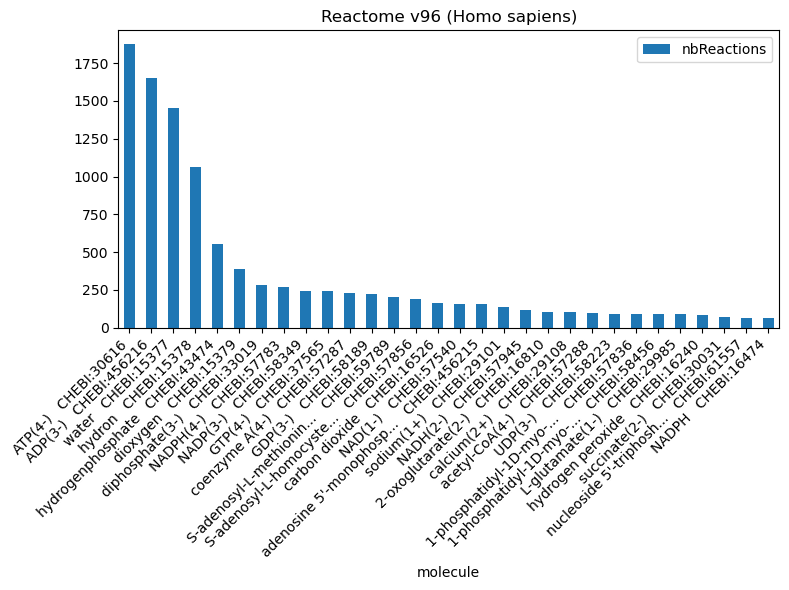

In [22]:
ax = dfMolecules.head(30).plot.bar(x="molecule", y="nbReactions", title="Reactome v{} (Homo sapiens)".format(reactomeVersion), figsize=(8, 6))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/reactome_version{}_hsa_chebiMoleculesNbReactions.svg".format(reactomeVersion), format="svg", bbox_inches="tight")

# 5. Molecule participation over-representation

## 5.1 Metrics computation

In [26]:
dfReactionToMolecule = pandas.read_csv("results/reactome_version{}_hsa_ReactionToMolecule.tsv.gz".format(reactomeVersion), sep = "\t")
dfMoleculeToReaction = pandas.read_csv("results/reactome_version{}_hsa_MoleculeToReaction.tsv.gz".format(reactomeVersion), sep = "\t")
dfMoleculeLabel = pandas.read_csv("results/reactome_version{}_hsa_chebiMolecules.tsv.gz".format(reactomeVersion), sep = "\t")

In [23]:
query = """
SELECT DISTINCT ?reactionFromIdent ?chebiID
WHERE {
  ?reactionFrom rdf:type/(rdfs:subClassOf*) bp3:BiochemicalReaction .
  ?reactionFrom bp3:xref [
    rdf:type bp3:UnificationXref ;
    bp3:db "Reactome" ;
    bp3:id ?reactionFromIdent
  ] .

  ?reactionFrom bp3:right ?moleculeFrom .

  ?moleculeFrom rdf:type bp3:SmallMolecule .
  ?moleculeFrom bp3:entityReference ?moleculeFromRef .
  ?moleculeFromRef bp3:xref ?moleculeFromRefChebi .
  ?moleculeFromRefChebi bp3:db "ChEBI" .
  ?moleculeFromRefChebi bp3:id ?chebiID .
  ?moleculeFromRefChebi rdf:type bp3:UnificationXref .

  #BIND(REPLACE(STR(?molecule), "http://purl.obolibrary.org/obo/CHEBI_", "CHEBI:") AS ?chebiID) # ChEBI URL -> ident
  BIND(IRI(REPLACE(?chebiID, "CHEBI:", "http://purl.obolibrary.org/obo/CHEBI_")) AS ?moleculeChebi) # ChEBI ident -> URL
  FILTER NOT EXISTS { ?moleculeChebi owl:deprecated "true"^^xsd:boolean . }
}
"""

#sparql = SPARQLWrapper(endpointURL)
#sparql.setQuery(prefixes+query)
#sparql.setReturnFormat(JSON)
#results = sparql.query().convert()
#
#displaySparqlResults(results)

df = sparqldataframe.query(endpointURL, prefixes+query)

print("Nb distinct reactions to produced molecules: {}".format(len(df)))
print("Nb distinct reactions producing >= 1 molecule: {}".format(len(df['reactionFromIdent'].unique())))
print("Nb distinct molecules produced by >= 1 reaction: {}".format(len(df['chebiID'].unique())))

df.to_csv("results/reactome_version{}_hsa_ReactionToMolecule.tsv.gz".format(reactomeVersion), sep="\t", header=True, index=False)

Nb distinct reactions to produced molecules: 8489
Nb distinct reactions producing >= 1 molecule: 5309
Nb distinct molecules produced by >= 1 reaction: 1347


In [24]:
query = """
SELECT DISTINCT ?reactionToIdent ?chebiID
WHERE {
  ?reactionTo rdf:type/(rdfs:subClassOf*) bp3:BiochemicalReaction .
  ?reactionTo bp3:xref [
    rdf:type bp3:UnificationXref ;
    bp3:db "Reactome" ;
    bp3:id ?reactionToIdent
  ] .

  ?reactionTo bp3:left ?moleculeTo .

  ?moleculeTo rdf:type bp3:SmallMolecule .
  ?moleculeTo bp3:entityReference ?moleculeToRef .
  ?moleculeToRef bp3:xref ?moleculeToRefChebi .
  ?moleculeToRefChebi bp3:db "ChEBI" .
  ?moleculeToRefChebi bp3:id ?chebiID .
  ?moleculeToRefChebi rdf:type bp3:UnificationXref .

  #BIND(REPLACE(STR(?molecule), "http://purl.obolibrary.org/obo/CHEBI_", "CHEBI:") AS ?chebiID) # ChEBI URL -> ident
  BIND(IRI(REPLACE(?chebiID, "CHEBI:", "http://purl.obolibrary.org/obo/CHEBI_")) AS ?moleculeChebi) # ChEBI ident -> URL
  FILTER NOT EXISTS { ?moleculeChebi owl:deprecated "true"^^xsd:boolean . }
}
"""

#sparql = SPARQLWrapper(endpointURL)
#sparql.setQuery(prefixes+query)
#sparql.setReturnFormat(JSON)
#results = sparql.query().convert()
#
#displaySparqlResults(results)

df = sparqldataframe.query(endpointURL, prefixes+query)

print("Nb distinct reactions to consumed molecules: {}".format(len(df)))
print("Nb distinct reactions consuming >= 1 molecule: {}".format(len(df['reactionToIdent'].unique())))
print("Nb distinct molecules consumed by >= 1 reaction: {}".format(len(df['chebiID'].unique())))

df.to_csv("results/reactome_version{}_hsa_MoleculeToReaction.tsv.gz".format(reactomeVersion), sep="\t", header=True, index=False)

Nb distinct reactions to consumed molecules: 9191
Nb distinct reactions consuming >= 1 molecule: 6074
Nb distinct molecules consumed by >= 1 reaction: 1229


In [25]:
query = """
SELECT DISTINCT ?reactionFromIdent ?reactionToIdent ?chebiID
WHERE {
  ?stepFrom rdf:type bp3:PathwayStep .
  ?stepFrom bp3:nextStep ?stepTo .
  ?stepTo rdf:type bp3:PathwayStep .

  ?stepFrom bp3:stepProcess ?reactionFrom .
  # Do not retrieve the control associated to the reaction of a PathwayStep
  FILTER NOT EXISTS {
    ?reactionFrom bp3:controlled/^bp3:stepProcess ?stepFrom .
  }

  ?stepTo bp3:stepProcess ?reactionTo .
  # Do not retrieve the control associated to the reaction of a PathwayStep
  FILTER NOT EXISTS {
    ?reactionTo bp3:controlled/^bp3:stepProcess ?stepTo .
  }
  
  ?reactionFrom rdf:type/(rdfs:subClassOf*) bp3:BiochemicalReaction .
  ?reactionFrom bp3:xref [
    rdf:type bp3:UnificationXref ;
    bp3:db "Reactome" ;
    bp3:id ?reactionFromIdent
  ] .

  ?reactionFrom bp3:right ?moleculeFrom .

  ?moleculeFrom rdf:type bp3:SmallMolecule .
  ?moleculeFrom bp3:entityReference ?moleculeFromRef .
  ?moleculeFromRef bp3:xref ?moleculeFromRefChebi .
  ?moleculeFromRefChebi bp3:db "ChEBI" .
  ?moleculeFromRefChebi bp3:id ?chebiID .
  ?moleculeFromRefChebi rdf:type bp3:UnificationXref .

  ?reactionTo rdf:type/(rdfs:subClassOf*) bp3:BiochemicalReaction .
  ?reactionTo bp3:xref [
    rdf:type bp3:UnificationXref ;
    bp3:db "Reactome" ;
    bp3:id ?reactionToIdent
  ] .

  ?reactionTo bp3:left ?moleculeTo .

  ?moleculeTo rdf:type bp3:SmallMolecule .
  ?moleculeTo bp3:entityReference ?moleculeToRef .
  ?moleculeToRef bp3:xref ?moleculeToRefChebi .
  ?moleculeToRefChebi bp3:db "ChEBI" .
  ?moleculeToRefChebi bp3:id ?chebiID .
  ?moleculeToRefChebi rdf:type bp3:UnificationXref .

  #BIND(REPLACE(STR(?molecule), "http://purl.obolibrary.org/obo/CHEBI_", "CHEBI:") AS ?chebiID) # ChEBI URL -> ident
  BIND(IRI(REPLACE(?chebiID, "CHEBI:", "http://purl.obolibrary.org/obo/CHEBI_")) AS ?moleculeChebi) # ChEBI ident -> URL
  FILTER NOT EXISTS { ?moleculeChebi owl:deprecated "true"^^xsd:boolean . }
}
"""

#sparql = SPARQLWrapper(endpointURL)
#sparql.setQuery(prefixes+query)
#sparql.setReturnFormat(JSON)
#results = sparql.query().convert()
#
#displaySparqlResults(results)

df = sparqldataframe.query(endpointURL, prefixes+query)

print("Nb distinct biologically pairs reactions and molecules: {}".format(len(df)))
print("Nb distinct biologically pairs reactions: {}".format(len(df[['reactionFromIdent', 'reactionToIdent']].value_counts())))
print("Nb distinct molecules produced by >= 1 reaction: {}".format(len(df['chebiID'].unique())))

df.to_csv("results/reactome_version{}_hsa_ReactionToMoleculeToReactionBiologicallyRelevant.tsv.gz".format(reactomeVersion), sep="\t", header=True, index=False)

Nb distinct biologically pairs reactions and molecules: 2774
Nb distinct biologically pairs reactions: 2625
Nb distinct molecules produced by >= 1 reaction: 837


In [9]:
dfReactionToMoleculeToReactionChemicallyPossible = dfReactionToMolecule.join(dfMoleculeToReaction.set_index('chebiID'), on = 'chebiID', how = 'inner')
dfReactionToMoleculeToReactionChemicallyPossible.to_csv("results/reactome_version{}_hsa_ReactionToMoleculeToReactionChemicallyPossible.tsv.gz".format(reactomeVersion), sep="\t", header=True, index=False)
print("Nb reaction-molecule-reaction chemically possible: {}".format(len(dfReactionToMoleculeToReactionChemicallyPossible)))
print("Nb reaction-molecule-reaction chemically possible: {}".format(len(dfReactionToMoleculeToReactionChemicallyPossible[['reactionFromIdent', 'reactionToIdent']].drop_duplicates())))
dfReactionToMoleculeToReactionChemicallyPossible.head()

Nb reaction-molecule-reaction chemically possible: 884913


,reactionFromIdent,chebiID,reactionToIdent
0,R-HSA-74615,CHEBI:456216,R-HSA-110133
0,R-HSA-74615,CHEBI:456216,R-HSA-417829
0,R-HSA-74615,CHEBI:456216,R-HSA-482621
0,R-HSA-74615,CHEBI:456216,R-HSA-5444516
0,R-HSA-74615,CHEBI:456216,R-HSA-482812


In [12]:
dfMoleculeLabel.join(dfReactionToMoleculeToReactionChemicallyPossible['chebiID'].value_counts().to_frame(), on = 'chebiID', how = 'inner').sort_values(by = 'count', ascending = False)

,chebiID,moleculeChebiLabel,count
917,CHEBI:15377,water,351120
1493,CHEBI:15378,hydron,323202
1572,CHEBI:30616,ATP(4-),46425
748,CHEBI:456216,ADP(3-),42406
1857,CHEBI:43474,hydrogenphosphate,16864
...,...,...,...
1975,CHEBI:64567,lysophosphatidylcholine 22:6,1
1972,CHEBI:180689,6 thiodeoxyguanosine monophosphate (2-),1
1964,CHEBI:57524,O-phosphonato-L-serine(2-),1
33,CHEBI:57538,orotidine 5'-phosphate(3-),1


In [10]:
dfMoleculeReactionPairsChemicallyPossible = dfMoleculeLabel.join(dfReactionToMoleculeToReactionChemicallyPossible['chebiID'].value_counts().to_frame(), on = 'chebiID', how = 'inner').sort_values(by = 'count', ascending = False)

dfMoleculeReactionPairsChemicallyPossible.to_csv("results/reactome_version{}_hsa_MoleculeReactionPairsChemicallyPossible.tsv.gz".format(reactomeVersion), sep="\t", header=True, index=False)

dfMoleculeReactionPairsChemicallyPossible.head()

NameError: name 'dfMoleculeLabel' is not defined

## 5.2 Metrics loading

In [37]:
dfReactionToMolecule = pandas.read_csv("results/reactome_version{}_hsa_ReactionToMolecule.tsv.gz".format(reactomeVersion), sep = "\t")
dfMoleculeToReaction = pandas.read_csv("results/reactome_version{}_hsa_MoleculeToReaction.tsv.gz".format(reactomeVersion), sep = "\t")
dfReactionToMoleculeToReactionChemicallyPossible = pandas.read_csv("results/reactome_version{}_hsa_ReactionToMoleculeToReactionChemicallyPossible.tsv.gz".format(reactomeVersion), sep = "\t")
dfReactionToMoleculeToReactionBiologicallyRelevant = pandas.read_csv("results/reactome_version{}_hsa_ReactionToMoleculeToReactionBiologicallyRelevant.tsv.gz".format(reactomeVersion), sep = "\t")
dfMoleculeLabel = pandas.read_csv("results/reactome_version{}_hsa_chebiMolecules.tsv.gz".format(reactomeVersion), sep = "\t")

dfMoleculeReactionPairsChemicallyPossible = pandas.read_csv("results/reactome_version{}_hsa_MoleculeReactionPairsChemicallyPossible.tsv.gz".format(reactomeVersion), sep = "\t")
# computed below
#dfMoleculeReactionPairsBiologicallyRelevant = pandas.read_csv("results/reactome_version{}_hsa_MoleculeReactionPairsBiologicallyRelevant.tsv.gz".format(reactomeVersion), sep = "\t")

print(dfReactionToMolecule)
print()
print(dfMoleculeToReaction)

     reactionFromIdent       chebiID
0          R-HSA-74615  CHEBI:456216
1        R-HSA-9929360  CHEBI:456216
2        R-HSA-9712082  CHEBI:456216
3         R-HSA-390251   CHEBI:15378
4         R-HSA-390251   CHEBI:57945
...                ...           ...
8484     R-HSA-2161789   CHEBI:57410
8485     R-HSA-2161789   CHEBI:15378
8486     R-HSA-9861725   CHEBI:43474
8487      R-HSA-469659   CHEBI:16330
8488      R-HSA-469659   CHEBI:58349

[8489 rows x 2 columns]

     reactionToIdent      chebiID
0        R-HSA-74615  CHEBI:30616
1       R-HSA-420688  CHEBI:59888
2      R-HSA-9929360  CHEBI:30616
3      R-HSA-9712082  CHEBI:30616
4       R-HSA-202692  CHEBI:57836
...              ...          ...
9186   R-HSA-2161789  CHEBI:57409
9187   R-HSA-9861725  CHEBI:15377
9188    R-HSA-469659  CHEBI:57783
9189    R-HSA-469659  CHEBI:17347
9190    R-HSA-469659  CHEBI:15378

[9191 rows x 2 columns]


In [38]:
dfMoleculeReactionPairsChemicallyPossible.head()

,chebiID,moleculeChebiLabel,count
0,CHEBI:15377,water,351120
1,CHEBI:15378,hydron,323202
2,CHEBI:30616,ATP(4-),46425
3,CHEBI:456216,ADP(3-),42406
4,CHEBI:43474,hydrogenphosphate,16864


In [25]:
dfMoleculeLabel = pandas.read_csv("results/reactome_version{}_hsa_chebiMolecules.tsv.gz".format(reactomeVersion), sep = "\t")

print("Nb molecules with label: {}".format(len(dfMoleculeLabel['chebiID'].unique())))
print()
dfMoleculeLabel.head()

Nb molecules with label: 2055



,chebiID,moleculeChebiLabel
0,CHEBI:58698,molybdopterin(3-)
1,CHEBI:140382,"(4Z,8E,10Z,13Z,16Z,19Z)-7-oxodocosahexaenoate"
2,CHEBI:2453,acyclovir
3,CHEBI:28540,"5beta-cholestane-3alpha,7alpha,26-triol"
4,CHEBI:17682,benzoin


In [27]:
dfReactionToMoleculeToReactionChemicallyPossible.head()

,reactionFromIdent,chebiID,reactionToIdent
0,R-HSA-74615,CHEBI:456216,R-HSA-110133
1,R-HSA-74615,CHEBI:456216,R-HSA-417829
2,R-HSA-74615,CHEBI:456216,R-HSA-482621
3,R-HSA-74615,CHEBI:456216,R-HSA-5444516
4,R-HSA-74615,CHEBI:456216,R-HSA-482812


## 5.3 Chemically-possible sequences of reactions

In [15]:
dfMoleculeReactionPairsChemicallyPossible.head()

,reactionFromIdent,chebiID,reactionToIdent
0,R-HSA-74615,CHEBI:456216,R-HSA-110133
1,R-HSA-74615,CHEBI:456216,R-HSA-417829
2,R-HSA-74615,CHEBI:456216,R-HSA-482621
3,R-HSA-74615,CHEBI:456216,R-HSA-5444516
4,R-HSA-74615,CHEBI:456216,R-HSA-482812


In [10]:
res = []
for i, row in dfMoleculeReactionPairsChemicallyPossible.iterrows():
    res.append(row['moleculeChebiLabel'] + "   " + row['chebiID'] if len(row['moleculeChebiLabel']) < 25 else row['moleculeChebiLabel'][:22] + "...   " + row['chebiID'] )
    #res.append(row['moleculeChebiLabel'] if len(row['moleculeChebiLabel']) < 25 else row['moleculeChebiLabel'][:22] + "...   " )
dfMoleculeReactionPairsChemicallyPossible['molecule'] = res

KeyError: 'moleculeChebiLabel'

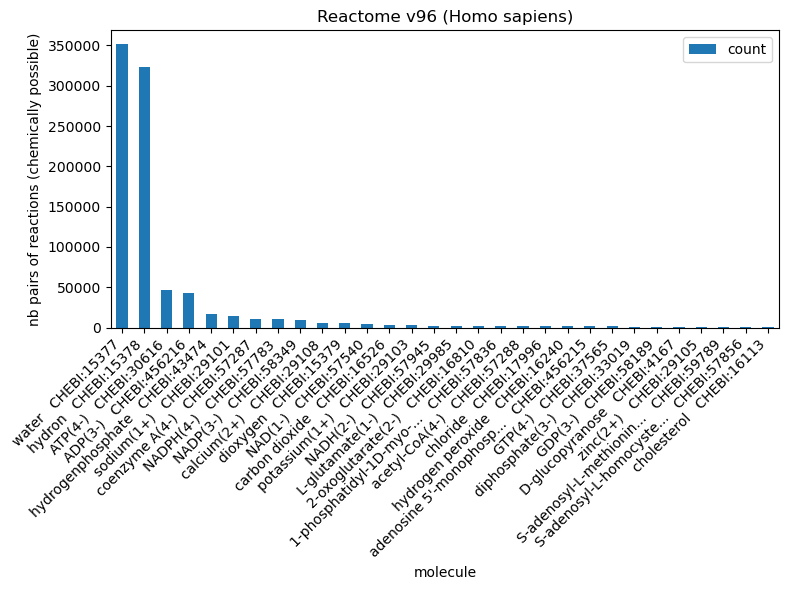

In [36]:
ax = dfMoleculeReactionPairsChemicallyPossible.head(30).plot.bar(x="molecule", y="count", ylabel="nb pairs of reactions (chemically possible)", title="Reactome v{} (Homo sapiens)".format(reactomeVersion), figsize=(8, 6))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/reactome_version{}_hsa_chebiMoleculesNbReactionPairs_chemicallyPossible.svg".format(reactomeVersion), format="svg", bbox_inches="tight")

## 5.4 Biologically-relevant sequences of reactions

In [39]:
dfReactionToMoleculeToReactionBiologicallyRelevant[['reactionFromIdent', 'reactionToIdent']].value_counts()

reactionFromIdent  reactionToIdent
R-HSA-192042       R-HSA-192054       3
R-HSA-2161779      R-HSA-2161844      3
R-HSA-194642       R-HSA-194689       3
R-HSA-193497       R-HSA-193460       3
R-HSA-450971       R-HSA-163217       2
                                     ..
R-HSA-191382       R-HSA-191322       1
                   R-HSA-9717834      1
R-HSA-191402       R-HSA-191299       1
R-HSA-191405       R-HSA-191402       1
R-HSA-191322       R-HSA-191303       1
Name: count, Length: 2625, dtype: int64

In [40]:
dfReactionToMoleculeToReactionBiologicallyRelevant['chebiID'].value_counts()

chebiID
CHEBI:15378     130
CHEBI:57836      45
CHEBI:203600     42
CHEBI:57880      39
CHEBI:29105      39
               ... 
CHEBI:58266       1
CHEBI:65139       1
CHEBI:78550       1
CHEBI:52392       1
CHEBI:16897       1
Name: count, Length: 837, dtype: int64

In [41]:
dfMoleculeReactionPairsBiologicallyRelevant = dfMoleculeLabel.join(dfReactionToMoleculeToReactionBiologicallyRelevant['chebiID'].value_counts().to_frame(), on = 'chebiID', how = 'inner').sort_values(by = 'count', ascending = False)
dfMoleculeReactionPairsBiologicallyRelevant.to_csv("results/reactome_version{}_hsa_MoleculeReactionPairsBiologicallyRelevant.tsv.gz".format(reactomeVersion), sep="\t", header=True, index=False)

dfMoleculeReactionPairsBiologicallyRelevant.head()

,chebiID,moleculeChebiLabel,count
1493,CHEBI:15378,hydron,130
18,CHEBI:57836,"1-phosphatidyl-1D-myo-inositol 3,4,5-trisphosp...",45
517,CHEBI:203600,"1D-myo-inositol 1,4,5-trisphosphate(6-)",42
856,CHEBI:29105,zinc(2+),39
355,CHEBI:57880,1-phosphatidyl-1D-myo-inositol(1-),39


In [40]:
res = []
for i, row in dfMoleculeReactionPairsBiologicallyRelevant.iterrows():
    res.append(row['moleculeChebiLabel'] + "   " + row['chebiID'] if len(row['moleculeChebiLabel']) < 25 else row['moleculeChebiLabel'][:22] + "...   " + row['chebiID'] )
    #res.append(row['moleculeChebiLabel'] if len(row['moleculeChebiLabel']) < 25 else row['moleculeChebiLabel'][:22] + "...   " )
dfMoleculeReactionPairsBiologicallyRelevant['molecule'] = res

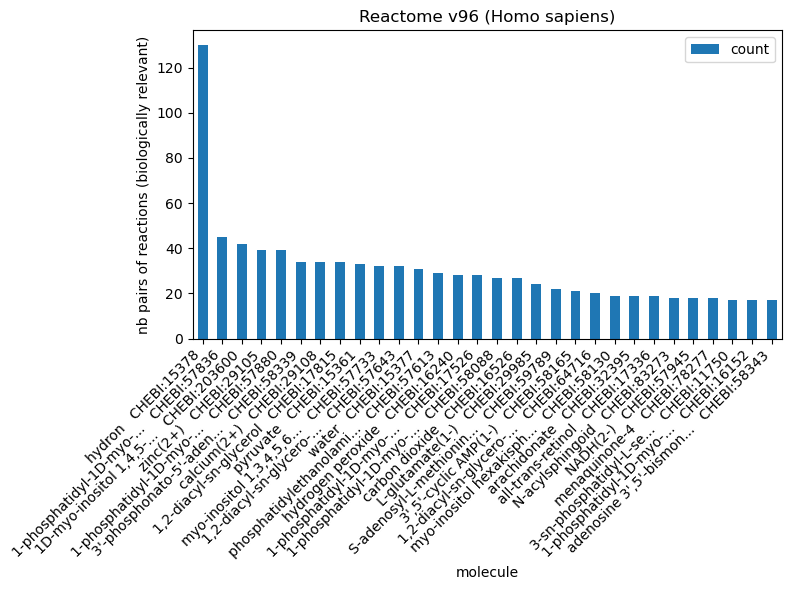

In [41]:
ax = dfMoleculeReactionPairsBiologicallyRelevant.head(30).plot.bar(x="molecule", y="count", ylabel="nb pairs of reactions (biologically relevant)", title="Reactome v{} (Homo sapiens)".format(reactomeVersion), figsize=(8, 6))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figures/reactome_version{}_hsa_chebiMoleculesNbReactionPairs_biologicallyRelevant.svg".format(reactomeVersion), format="svg", bbox_inches="tight")

## 5.5 Over-represented molecules in chemically-possible sequences of reactions

In [42]:
dfReactionToMolecule = pandas.read_csv("results/reactome_version{}_hsa_ReactionToMolecule.tsv.gz".format(reactomeVersion), sep = "\t")
dfMoleculeToReaction = pandas.read_csv("results/reactome_version{}_hsa_MoleculeToReaction.tsv.gz".format(reactomeVersion), sep = "\t")
dfReactionToMoleculeToReactionChemicallyPossible = pandas.read_csv("results/reactome_version{}_hsa_ReactionToMoleculeToReactionChemicallyPossible.tsv.gz".format(reactomeVersion), sep = "\t")
dfReactionToMoleculeToReactionBiologicallyRelevant = pandas.read_csv("results/reactome_version{}_hsa_ReactionToMoleculeToReactionBiologicallyRelevant.tsv.gz".format(reactomeVersion), sep = "\t")

dfMoleculeReactionPairsChemicallyPossible = pandas.read_csv("results/reactome_version{}_hsa_MoleculeReactionPairsChemicallyPossible.tsv.gz".format(reactomeVersion), sep = "\t")
dfMoleculeReactionPairsBiologicallyRelevant = pandas.read_csv("results/reactome_version{}_hsa_MoleculeReactionPairsBiologicallyRelevant.tsv.gz".format(reactomeVersion), sep = "\t")


In [43]:
dfMoleculeReactionPairsChemicallyPossible.head()

,chebiID,moleculeChebiLabel,count
0,CHEBI:15377,water,351120
1,CHEBI:15378,hydron,323202
2,CHEBI:30616,ATP(4-),46425
3,CHEBI:456216,ADP(3-),42406
4,CHEBI:43474,hydrogenphosphate,16864


In [44]:
nbReactionPairsChemicallyPossible = len(dfReactionToMoleculeToReactionChemicallyPossible[['reactionFromIdent', 'reactionToIdent']].value_counts())
print("Nb distinct chemically-possible pairs of reactions: {}".format(nbReactionPairsChemicallyPossible))

Nb distinct chemically-possible pairs of reactions: 873992


In [31]:
dfReactionToMoleculeToReactionBiologicallyRelevant.head()

,reactionFromIdent,reactionToIdent,chebiID
0,R-HSA-2046099,R-HSA-2046087,CHEBI:63540
1,R-HSA-1678716,R-HSA-1678708,CHEBI:63805
2,R-HSA-2162226,R-HSA-2162229,CHEBI:4178
3,R-HSA-159790,R-HSA-159752,CHEBI:78277
4,R-HSA-159790,R-HSA-159803,CHEBI:78277


In [45]:
nbReactionPairsBiologicallyRelevant = len(dfReactionToMoleculeToReactionBiologicallyRelevant[['reactionFromIdent', 'reactionToIdent']].value_counts())
print("Nb distinct biologically-relevant pairs of reactions: {}".format(nbReactionPairsBiologicallyRelevant))

Nb distinct biologically-relevant pairs of reactions: 2625


In [46]:
dfReactionToMoleculeToReactionBiologicallyRelevant[['reactionFromIdent', 'reactionToIdent']].value_counts()

reactionFromIdent  reactionToIdent
R-HSA-192042       R-HSA-192054       3
R-HSA-2161779      R-HSA-2161844      3
R-HSA-194642       R-HSA-194689       3
R-HSA-193497       R-HSA-193460       3
R-HSA-450971       R-HSA-163217       2
                                     ..
R-HSA-191382       R-HSA-191322       1
                   R-HSA-9717834      1
R-HSA-191402       R-HSA-191299       1
R-HSA-191405       R-HSA-191402       1
R-HSA-191322       R-HSA-191303       1
Name: count, Length: 2625, dtype: int64

In [47]:
dfMoleculeReactionPairsChemicallyPossible['freq'] = dfMoleculeReactionPairsChemicallyPossible['count'] / nbReactionPairsChemicallyPossible
dfMoleculeReactionPairsBiologicallyRelevant['freq'] = dfMoleculeReactionPairsBiologicallyRelevant['count'] / nbReactionPairsBiologicallyRelevant

In [48]:
print(dfMoleculeReactionPairsChemicallyPossible.head())
print()
print(dfMoleculeReactionPairsBiologicallyRelevant.head())

        chebiID moleculeChebiLabel   count      freq
0   CHEBI:15377              water  351120  0.401743
1   CHEBI:15378             hydron  323202  0.369800
2   CHEBI:30616            ATP(4-)   46425  0.053118
3  CHEBI:456216            ADP(3-)   42406  0.048520
4   CHEBI:43474  hydrogenphosphate   16864  0.019295

        chebiID                                 moleculeChebiLabel  count  \
0   CHEBI:15378                                             hydron    130   
1   CHEBI:57836  1-phosphatidyl-1D-myo-inositol 3,4,5-trisphosp...     45   
2  CHEBI:203600            1D-myo-inositol 1,4,5-trisphosphate(6-)     42   
3   CHEBI:29105                                           zinc(2+)     39   
4   CHEBI:57880                 1-phosphatidyl-1D-myo-inositol(1-)     39   

       freq  
0  0.049524  
1  0.017143  
2  0.016000  
3  0.014857  
4  0.014857  


In [49]:
moleculesChemicallyPossible = set(dfMoleculeReactionPairsChemicallyPossible['chebiID'])
moleculesBiologicallyRelevant = set(dfMoleculeReactionPairsBiologicallyRelevant['chebiID'])
print("Nb distinct ChEBI identifiers chemically-possible: {}".format(len(moleculesChemicallyPossible)))
print("Nb distinct ChEBI identifiers biologically-relevant: {}".format(len(moleculesBiologicallyRelevant)))
print("Nb distinct ChEBI identifiers common: {}".format(len(moleculesChemicallyPossible.intersection(moleculesBiologicallyRelevant))))

Nb distinct ChEBI identifiers chemically-possible: 973
Nb distinct ChEBI identifiers biologically-relevant: 837
Nb distinct ChEBI identifiers common: 837


In [50]:
dfMoleculesChemicallyPossibleBiologicallyRelevant = dfMoleculeReactionPairsChemicallyPossible[['chebiID', 'count']].copy().rename(columns={'count': 'countChemicallyPossible'})
dfMoleculesChemicallyPossibleBiologicallyRelevant.head()

,chebiID,countChemicallyPossible
0,CHEBI:15377,351120
1,CHEBI:15378,323202
2,CHEBI:30616,46425
3,CHEBI:456216,42406
4,CHEBI:43474,16864


In [51]:
dfMoleculesChemicallyPossibleBiologicallyRelevant = dfMoleculesChemicallyPossibleBiologicallyRelevant.join(dfMoleculeReactionPairsBiologicallyRelevant[['chebiID', 'count']].set_index('chebiID'), on='chebiID', how='inner').rename(columns={'count': 'countBiologicallyRelevant'})
dfMoleculesChemicallyPossibleBiologicallyRelevant.head()

,chebiID,countChemicallyPossible,countBiologicallyRelevant
0,CHEBI:15377,351120,31
1,CHEBI:15378,323202,130
2,CHEBI:30616,46425,7
3,CHEBI:456216,42406,6
4,CHEBI:43474,16864,2


In [52]:
dfMoleculesChemicallyPossibleBiologicallyRelevant = dfMoleculesChemicallyPossibleBiologicallyRelevant.join(dfMoleculeLabel.set_index('chebiID'), on='chebiID', how='inner')
dfMoleculesChemicallyPossibleBiologicallyRelevant.head()

,chebiID,countChemicallyPossible,countBiologicallyRelevant,moleculeChebiLabel
0,CHEBI:15377,351120,31,water
1,CHEBI:15378,323202,130,hydron
2,CHEBI:30616,46425,7,ATP(4-)
3,CHEBI:456216,42406,6,ADP(3-)
4,CHEBI:43474,16864,2,hydrogenphosphate


In [53]:
dfMoleculesChemicallyPossibleBiologicallyRelevant['freqChemicallyPossible'] = dfMoleculesChemicallyPossibleBiologicallyRelevant['countChemicallyPossible'] / nbReactionPairsChemicallyPossible
dfMoleculesChemicallyPossibleBiologicallyRelevant['freqBiologicallyRelevant'] = dfMoleculesChemicallyPossibleBiologicallyRelevant['countBiologicallyRelevant'] / nbReactionPairsBiologicallyRelevant
dfMoleculesChemicallyPossibleBiologicallyRelevant.head()

,chebiID,countChemicallyPossible,countBiologicallyRelevant,moleculeChebiLabel,freqChemicallyPossible,freqBiologicallyRelevant
0,CHEBI:15377,351120,31,water,0.401743,0.011810
1,CHEBI:15378,323202,130,hydron,0.369800,0.049524
2,CHEBI:30616,46425,7,ATP(4-),0.053118,0.002667
3,CHEBI:456216,42406,6,ADP(3-),0.048520,0.002286
4,CHEBI:43474,16864,2,hydrogenphosphate,0.019295,0.000762


In [54]:
dfMoleculesChemicallyPossibleBiologicallyRelevant["pValueBackgroundChemicallyPossible"] = stats.hypergeom.cdf(dfMoleculesChemicallyPossibleBiologicallyRelevant['countBiologicallyRelevant']-1, nbReactionPairsChemicallyPossible, dfMoleculesChemicallyPossibleBiologicallyRelevant['countChemicallyPossible'], nbReactionPairsBiologicallyRelevant)
dfMoleculesChemicallyPossibleBiologicallyRelevant["adjPvalueBackgroundChemicallyPossible"] = stats.false_discovery_control(dfMoleculesChemicallyPossibleBiologicallyRelevant["pValueBackgroundChemicallyPossible"]) # Benjamini-Hochberg
#dfMoleculesChemicallyPossibleBiologicallyRelevant["adjPvalueBackgroundChemicallyPossible2"] = statsmodels.stats.multitest.multipletests(dfMoleculesChemicallyPossibleBiologicallyRelevant["pValueBackgroundChemicallyPossible"], alpha=0.05, method='fdr_bh', is_sorted=False, returnsorted=False)[1]

dfMoleculesChemicallyPossibleBiologicallyRelevant["pValueBackgroundBiologicallyRelevant"] = stats.hypergeom.sf(dfMoleculesChemicallyPossibleBiologicallyRelevant['countBiologicallyRelevant']-1, nbReactionPairsChemicallyPossible, dfMoleculesChemicallyPossibleBiologicallyRelevant['countChemicallyPossible'], nbReactionPairsBiologicallyRelevant)
dfMoleculesChemicallyPossibleBiologicallyRelevant["adjPvalueBackgroundBiologicallyRelevant"] = stats.false_discovery_control(dfMoleculesChemicallyPossibleBiologicallyRelevant["pValueBackgroundBiologicallyRelevant"])
#dfMoleculesChemicallyPossibleBiologicallyRelevant["adjPvalueBackgroundBiologicallyRelevant2"] = statsmodels.stats.multitest.multipletests(dfMoleculesChemicallyPossibleBiologicallyRelevant["pValueBackgroundBiologicallyRelevant"], alpha=0.05, method='fdr_bh', is_sorted=False, returnsorted=False)[1]

In [55]:
dfMoleculesChemicallyPossibleBiologicallyRelevant.head()

,chebiID,countChemicallyPossible,countBiologicallyRelevant,moleculeChebiLabel,freqChemicallyPossible,freqBiologicallyRelevant,pValueBackgroundChemicallyPossible,adjPvalueBackgroundChemicallyPossible,pValueBackgroundBiologicallyRelevant,adjPvalueBackgroundBiologicallyRelevant
0,CHEBI:15377,351120,31,water,0.401743,0.011810,0.000000e+00,0.000000e+00,1.0,1.0
1,CHEBI:15378,323202,130,hydron,0.369800,0.049524,0.000000e+00,0.000000e+00,1.0,1.0
2,CHEBI:30616,46425,7,ATP(4-),0.053118,0.002667,7.156894e-53,1.996774e-50,1.0,1.0
3,CHEBI:456216,42406,6,ADP(3-),0.048520,0.002286,6.128287e-49,1.282344e-46,1.0,1.0
4,CHEBI:43474,16864,2,hydrogenphosphate,0.019295,0.000762,2.997650e-21,5.018067e-19,1.0,1.0


In [61]:
dfMoleculesChemicallyPossibleBiologicallyRelevant[dfMoleculesChemicallyPossibleBiologicallyRelevant['adjPvalueBackgroundChemicallyPossible'] <= 0.05]

,chebiID,countChemicallyPossible,countBiologicallyRelevant,moleculeChebiLabel,freqChemicallyPossible,freqBiologicallyRelevant,pValueBackgroundChemicallyPossible,adjPvalueBackgroundChemicallyPossible,pValueBackgroundBiologicallyRelevant,adjPvalueBackgroundBiologicallyRelevant
917,CHEBI:15377,351120,31,water,0.401743,0.011810,0.000000e+00,0.000000e+00,1.000000,1.0
1493,CHEBI:15378,323202,130,hydron,0.369800,0.049524,0.000000e+00,0.000000e+00,1.000000,1.0
1572,CHEBI:30616,46425,7,ATP(4-),0.053118,0.002667,7.156894e-53,1.996774e-50,1.000000,1.0
748,CHEBI:456216,42406,6,ADP(3-),0.048520,0.002286,6.128287e-49,1.282344e-46,1.000000,1.0
1857,CHEBI:43474,16864,2,hydrogenphosphate,0.019295,0.000762,2.997650e-21,5.018067e-19,1.000000,1.0
1731,CHEBI:29101,14688,11,sodium(1+),0.016806,0.004190,5.242048e-10,7.312658e-08,1.000000,1.0
1333,CHEBI:57287,11022,9,coenzyme A(4-),0.012611,0.003429,1.681774e-07,2.010921e-05,1.000000,1.0
1225,CHEBI:57783,10258,8,NADPH(4-),0.011737,0.003048,2.426223e-07,2.538436e-05,1.000000,1.0
647,CHEBI:58349,9000,7,NADP(3-),0.010298,0.002667,1.121694e-06,1.043176e-04,0.999999,1.0
143,CHEBI:57540,4158,3,NAD(1-),0.004757,0.001143,3.330391e-04,2.787537e-02,0.999667,1.0


In [62]:
dfMoleculesChemicallyPossibleBiologicallyRelevant[dfMoleculesChemicallyPossibleBiologicallyRelevant['adjPvalueBackgroundBiologicallyRelevant'] >= 0.05]

,chebiID,countChemicallyPossible,countBiologicallyRelevant,moleculeChebiLabel,freqChemicallyPossible,freqBiologicallyRelevant,pValueBackgroundChemicallyPossible,adjPvalueBackgroundChemicallyPossible,pValueBackgroundBiologicallyRelevant,adjPvalueBackgroundBiologicallyRelevant
917,CHEBI:15377,351120,31,water,0.401743,0.011810,0.000000e+00,0.000000e+00,1.000000,1.000000
1493,CHEBI:15378,323202,130,hydron,0.369800,0.049524,0.000000e+00,0.000000e+00,1.000000,1.000000
1572,CHEBI:30616,46425,7,ATP(4-),0.053118,0.002667,7.156894e-53,1.996774e-50,1.000000,1.000000
748,CHEBI:456216,42406,6,ADP(3-),0.048520,0.002286,6.128287e-49,1.282344e-46,1.000000,1.000000
1857,CHEBI:43474,16864,2,hydrogenphosphate,0.019295,0.000762,2.997650e-21,5.018067e-19,1.000000,1.000000
1731,CHEBI:29101,14688,11,sodium(1+),0.016806,0.004190,5.242048e-10,7.312658e-08,1.000000,1.000000
1333,CHEBI:57287,11022,9,coenzyme A(4-),0.012611,0.003429,1.681774e-07,2.010921e-05,1.000000,1.000000
1225,CHEBI:57783,10258,8,NADPH(4-),0.011737,0.003048,2.426223e-07,2.538436e-05,1.000000,1.000000
647,CHEBI:58349,9000,7,NADP(3-),0.010298,0.002667,1.121694e-06,1.043176e-04,0.999999,1.000000
143,CHEBI:57540,4158,3,NAD(1-),0.004757,0.001143,3.330391e-04,2.787537e-02,0.999667,1.000000


In [63]:
dfMoleculesChemicallyPossibleBiologicallyRelevant.to_csv("results/reactome_version{}_hsa_MoleculesChemicallyPossibleBiologicallyRelevant.tsv.gz".format(reactomeVersion), sep="\t", header=True, index=False)


## 5.6 scatterplot

In [31]:
dfMoleculesChemicallyPossibleBiologicallyRelevant.head()

,chebiID,countChemicallyPossible,countBiologicallyRelevant,moleculeChebiLabel,freqChemicallyPossible,freqBiologicallyRelevant,pValueBackgroundChemicallyPossible,adjPvalueBackgroundChemicallyPossible,pValueBackgroundBiologicallyRelevant,adjPvalueBackgroundBiologicallyRelevant
917,CHEBI:15377,351120,31,water,0.401743,0.011810,0.000000e+00,0.000000e+00,1.0,1.0
1493,CHEBI:15378,323202,130,hydron,0.369800,0.049524,0.000000e+00,0.000000e+00,1.0,1.0
1572,CHEBI:30616,46425,7,ATP(4-),0.053118,0.002667,7.156894e-53,1.996774e-50,1.0,1.0
748,CHEBI:456216,42406,6,ADP(3-),0.048520,0.002286,6.128287e-49,1.282344e-46,1.0,1.0
1857,CHEBI:43474,16864,2,hydrogenphosphate,0.019295,0.000762,2.997650e-21,5.018067e-19,1.0,1.0


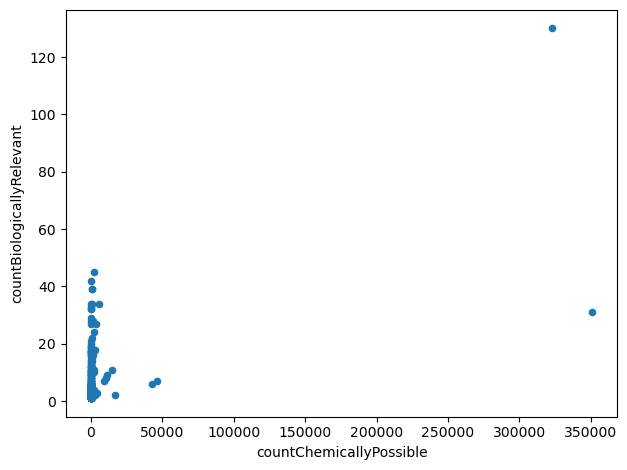

In [32]:
#ax = dfMoleculeReactionPairsBiologicallyRelevant.head(30).plot.bar(x="molecule", y="count", ylabel="nb pairs of reactions (biologically relevant)", title="Reactome v{} (Homo sapiens)".format(reactomeVersion), figsize=(8, 6))

ax = dfMoleculesChemicallyPossibleBiologicallyRelevant.plot.scatter(x="countChemicallyPossible", y="countBiologicallyRelevant")

plt.tight_layout()
plt.savefig("figures/reactome_version{}_hsa_chebiMoleculesNbReactionPairs_chemicallyPossible-biologicallyRelevant.svg".format(reactomeVersion), format="svg", bbox_inches="tight")

# TESTS

In [57]:
queryMoleculeReferencesList="""
# A bp3:SmallMoleculeReference connects two bp3:BiochemicalReactions

SELECT DISTINCT ?moleculeReference (SAMPLE(?moleculeName) AS ?moleculeLabel) (COUNT(*) AS ?nbReactionPairs)
WHERE {
  ?reaction1 rdf:type/(rdfs:subClassOf*) bp3:BiochemicalReaction .
  ?reaction1 bp3:right/bp3:entityReference ?moleculeReference .
  ?moleculeReference rdf:type/(rdfs:subClassOf*) bp3:SmallMoleculeReference .
  ?reaction2 bp3:left/bp3:entityReference ?moleculeReference .
  ?reaction2 rdf:type/(rdfs:subClassOf*) bp3:BiochemicalReaction .
  
  #constraintMoleculeUnicityClause#
  
  OPTIONAL { ?moleculeReference bp3:name ?moleculeName }
  
  #constraintBetweenReactionsClause#
}
GROUP BY ?moleculeReference 
ORDER BY DESC(?nbReactionPairs)
"""

df = sparqldataframe.query(endpointURL, prefixes+queryMoleculeReferencesList)
df['nbReactionPairs'] = pandas.to_numeric(df['nbReactionPairs'])
df

,moleculeReference,moleculeLabel,nbReactionPairs
0,http://www.reactome.org/biopax/96/48887#SmallM...,water [ChEBI:15377],702240
1,http://www.reactome.org/biopax/96/48887#SmallM...,hydron [ChEBI:15378],646404
2,http://www.reactome.org/biopax/96/48887#SmallM...,ATP(4-),232125
3,http://www.reactome.org/biopax/96/48887#SmallM...,ADP(3-),212030
4,http://www.reactome.org/biopax/96/48887#SmallM...,INORGANIC PHOSPHATE GROUP,151776
...,...,...,...
984,http://www.reactome.org/biopax/96/48887#SmallM...,squalene [ChEBI:15440],2
985,http://www.reactome.org/biopax/96/48887#SmallM...,thiamine(1+) triphosphate [ChEBI:9534],2
986,http://www.reactome.org/biopax/96/48887#SmallM...,trimethylenediamine [ChEBI:15725],2
987,http://www.reactome.org/biopax/96/48887#SmallM...,xylitol [ChEBI:17151],2


In [58]:
queryMoleculeReferencesList="""
# A bp3:SmallMoleculeReference connects two bp3:BiochemicalReactions

SELECT DISTINCT ?chebiID ?moleculeChebiLabel (COUNT(*) AS ?nbReactionPairs)
WHERE {
  {
    SELECT DISTINCT ?chebiID ?reaction1 ?reaction2
    WHERE {
      ?reaction1 rdf:type/(rdfs:subClassOf*) bp3:BiochemicalReaction .
      ?reaction1 bp3:right/bp3:entityReference ?moleculeReference .
      ?moleculeReference rdf:type/(rdfs:subClassOf*) bp3:SmallMoleculeReference .
      ?moleculeReference bp3:xref [
        rdf:type bp3:UnificationXref ;
        bp3:db "ChEBI" ;
        bp3:id ?chebiID
      ] .
      ?reaction2 bp3:left/bp3:entityReference ?moleculeReference .
      ?reaction2 rdf:type/(rdfs:subClassOf*) bp3:BiochemicalReaction .
    }
  }
  # ChEBI URL -> ident
  #BIND(REPLACE(STR(?molecule), "http://purl.obolibrary.org/obo/CHEBI_", "CHEBI:") AS ?chebiID) 
  #
  # ChEBI ident -> URL
  BIND(IRI(REPLACE(?chebiID, "CHEBI:", "http://purl.obolibrary.org/obo/CHEBI_")) AS ?moleculeChebi) 
  ?moleculeChebi rdfs:label ?moleculeChebiLabel .
}
GROUP BY ?chebiID ?moleculeChebiLabel
ORDER BY DESC(?nbReactionPairs)
"""

df = sparqldataframe.query(endpointURL, prefixes+queryMoleculeReferencesList)
df['nbReactionPairs'] = pandas.to_numeric(df['nbReactionPairs'])
df

,chebiID,moleculeChebiLabel,nbReactionPairs
0,CHEBI:15377,water,351120
1,CHEBI:15378,hydron,323202
2,CHEBI:30616,ATP(4-),46425
3,CHEBI:456216,ADP(3-),42406
4,CHEBI:43474,hydrogenphosphate,16864
...,...,...,...
968,CHEBI:90696,thromboxane B2(1-),1
969,CHEBI:90737,5-HEPE(1-),1
970,CHEBI:90815,"(4Z,7Z,10Z,14E,16Z,19Z)-13-hydroxydocosahexaen...",1
971,CHEBI:91279,alpha-D-Man-(1->3)-[alpha-D-Man-(1->6)]-beta-D...,1


# 6. Criticality

In [10]:
dfMoleculeLabel = pandas.read_csv("results/reactome_version{}_hsa_chebiMolecules.tsv.gz".format(reactomeVersion), sep = "\t")
dfReactionToMoleculeToReactionChemicallyPossible = pandas.read_csv("results/reactome_version{}_hsa_ReactionToMoleculeToReactionChemicallyPossible.tsv.gz".format(reactomeVersion), sep = "\t")
dfReactionToMoleculeToReactionBiologicallyRelevant = pandas.read_csv("results/reactome_version{}_hsa_ReactionToMoleculeToReactionBiologicallyRelevant.tsv.gz".format(reactomeVersion), sep = "\t")
dfMoleculesChemicallyPossibleBiologicallyRelevant = pandas.read_csv("results/reactome_version{}_hsa_MoleculesChemicallyPossibleBiologicallyRelevant.tsv.gz".format(reactomeVersion), sep="\t",)

In [11]:
nbReactionPairsChemicallyPossible = len(dfReactionToMoleculeToReactionChemicallyPossible[['reactionFromIdent', 'reactionToIdent']].value_counts())
print("Nb distinct chemically-possible pairs of reactions: {}".format(nbReactionPairsChemicallyPossible))
# 873992

nbReactionPairsBiologicallyRelevant = len(dfReactionToMoleculeToReactionBiologicallyRelevant[['reactionFromIdent', 'reactionToIdent']].value_counts())
print("Nb distinct biologically-relevant pairs of reactions: {}".format(nbReactionPairsBiologicallyRelevant))
# 20625

Nb distinct chemically-possible pairs of reactions: 873992
Nb distinct biologically-relevant pairs of reactions: 2625


In [12]:
dfMoleculesChemicallyPossibleBiologicallyRelevant['criticalityChemicallyPossible'] = 0.
dfMoleculesChemicallyPossibleBiologicallyRelevant['criticalityBiologicallyRelevant'] = 0.

dfMoleculesChemicallyPossibleBiologicallyRelevant['criticalityChemicallyPossibleDF'] = 0.
dfMoleculesChemicallyPossibleBiologicallyRelevant['criticalityBiologicallyRelevantDF'] = 0.

In [50]:
dfMoleculesChemicallyPossibleBiologicallyRelevant.head()

,chebiID,countChemicallyPossible,countBiologicallyRelevant,moleculeChebiLabel,freqChemicallyPossible,freqBiologicallyRelevant,pValueBackgroundChemicallyPossible,adjPvalueBackgroundChemicallyPossible,pValueBackgroundBiologicallyRelevant,adjPvalueBackgroundBiologicallyRelevant,criticalityChemicallyPossible,criticalityBiologicallyRelevant,criticalityChemicallyPossibleDF,criticalityBiologicallyRelevantDF
0,CHEBI:15377,351120,31,water,0.401743,0.011810,0.000000e+00,0.000000e+00,1.0,1.0,0.0,0.0,0.0,0.0
1,CHEBI:15378,323202,130,hydron,0.369800,0.049524,0.000000e+00,0.000000e+00,1.0,1.0,0.0,0.0,0.0,0.0
2,CHEBI:30616,46425,7,ATP(4-),0.053118,0.002667,7.156894e-53,1.996774e-50,1.0,1.0,0.0,0.0,0.0,0.0
3,CHEBI:456216,42406,6,ADP(3-),0.048520,0.002286,6.128287e-49,1.282344e-46,1.0,1.0,0.0,0.0,0.0,0.0
4,CHEBI:43474,16864,2,hydrogenphosphate,0.019295,0.000762,2.997650e-21,5.018067e-19,1.0,1.0,0.0,0.0,0.0,0.0


In [38]:
query = """
SELECT DISTINCT ?chebiID
WHERE {{
  VALUES ?reactionFromIdent {{ "{}" }}
  VALUES ?reactionToIdent {{ "{}" }}
  
  #?stepFrom rdf:type bp3:PathwayStep .
  #?stepFrom bp3:nextStep ?stepTo .
  #?stepTo rdf:type bp3:PathwayStep .
  #
  #?stepFrom bp3:stepProcess ?reactionFrom .
  ## Do not retrieve the control associated to the reaction of a PathwayStep
  #FILTER NOT EXISTS {{
  #  ?reactionFrom bp3:controlled/^bp3:stepProcess ?stepFrom .
  #}}
  #
  #?stepTo bp3:stepProcess ?reactionTo .
  ## Do not retrieve the control associated to the reaction of a PathwayStep
  #FILTER NOT EXISTS {{
  #  ?reactionTo bp3:controlled/^bp3:stepProcess ?stepTo .
  #}}
  
  ?reactionFrom rdf:type/(rdfs:subClassOf*) bp3:BiochemicalReaction .
  ?reactionFrom bp3:xref [
    rdf:type bp3:UnificationXref ;
    bp3:db "Reactome" ;
    bp3:id ?reactionFromIdent
  ] .

  ?reactionFrom bp3:right ?moleculeFrom .

  ?moleculeFrom rdf:type bp3:SmallMolecule .
  ?moleculeFrom bp3:entityReference ?moleculeFromRef .
  ?moleculeFromRef bp3:xref ?moleculeFromRefChebi .
  ?moleculeFromRefChebi bp3:db "ChEBI" .
  ?moleculeFromRefChebi bp3:id ?chebiID .
  ?moleculeFromRefChebi rdf:type bp3:UnificationXref .

  ?reactionTo rdf:type/(rdfs:subClassOf*) bp3:BiochemicalReaction .
  ?reactionTo bp3:xref [
    rdf:type bp3:UnificationXref ;
    bp3:db "Reactome" ;
    bp3:id ?reactionToIdent
  ] .

  ?reactionTo bp3:left ?moleculeTo .

  ?moleculeTo rdf:type bp3:SmallMolecule .
  ?moleculeTo bp3:entityReference ?moleculeToRef .
  ?moleculeToRef bp3:xref ?moleculeToRefChebi .
  ?moleculeToRefChebi bp3:db "ChEBI" .
  ?moleculeToRefChebi bp3:id ?chebiID .
  ?moleculeToRefChebi rdf:type bp3:UnificationXref .

  #BIND(REPLACE(STR(?molecule), "http://purl.obolibrary.org/obo/CHEBI_", "CHEBI:") AS ?chebiID) # ChEBI URL -> ident
  BIND(IRI(REPLACE(?chebiID, "CHEBI:", "http://purl.obolibrary.org/obo/CHEBI_")) AS ?moleculeChebi) # ChEBI ident -> URL
  FILTER NOT EXISTS {{ ?moleculeChebi owl:deprecated "true"^^xsd:boolean . }}
}}
"""

#query = query.format("R-HSA-109338", "R-HSA-109342") # 1 common molecule CHEBI:28387
query = query.format("R-HSA-109339", "R-HSA-163217") # 2 common molecules CHEBI:15378 CHEBI:57945

sparql = SPARQLWrapper(endpointURL)
sparql.setQuery(prefixes+query)
sparql.setReturnFormat(JSON)
results = sparql.query().convert()

print("Nb common molecules: {}".format(len(results)))
displaySparqlResults(results)

Nb common molecules: 2


chebiID
CHEBI:15378
CHEBI:57945


In [25]:
dfReactionToMoleculeToReactionBiologicallyRelevant[dfReactionToMoleculeToReactionBiologicallyRelevant['reactionToIdent'] == "R-HSA-163217"]

,reactionFromIdent,reactionToIdent,chebiID
30,R-HSA-109339,R-HSA-163217,CHEBI:15378
31,R-HSA-109339,R-HSA-163217,CHEBI:57945
369,R-HSA-77303,R-HSA-163217,CHEBI:15378
370,R-HSA-77303,R-HSA-163217,CHEBI:57945
585,R-HSA-164651,R-HSA-163217,CHEBI:15378
586,R-HSA-164651,R-HSA-163217,CHEBI:46245
1304,R-HSA-77323,R-HSA-163217,CHEBI:15378
1305,R-HSA-77323,R-HSA-163217,CHEBI:57945
1325,R-HSA-109342,R-HSA-163217,CHEBI:15378
1326,R-HSA-109342,R-HSA-163217,CHEBI:57945


In [55]:
moleculeCoOccurrenceBiologicallyRelevenant = collections.defaultdict(lambda: collections.defaultdict(int))
#for r in dfReactionToMoleculeToReactionBiologicallyRelevant[['reactionFromIdent', 'reactionToIdent']].drop_duplicates().head().itertuples():
for r in dfReactionToMoleculeToReactionBiologicallyRelevant[['reactionFromIdent', 'reactionToIdent']].drop_duplicates().itertuples():
    print("{}\t{}".format(r.reactionFromIdent, r.reactionToIdent))
    query = """
SELECT DISTINCT ?chebiID
WHERE {{
  VALUES ?reactionFromIdent {{ "{}" }}
  VALUES ?reactionToIdent {{ "{}" }}
  
  #?stepFrom rdf:type bp3:PathwayStep .
  #?stepFrom bp3:nextStep ?stepTo .
  #?stepTo rdf:type bp3:PathwayStep .
  #
  #?stepFrom bp3:stepProcess ?reactionFrom .
  ## Do not retrieve the control associated to the reaction of a PathwayStep
  #FILTER NOT EXISTS {{
  #  ?reactionFrom bp3:controlled/^bp3:stepProcess ?stepFrom .
  #}}
  #
  #?stepTo bp3:stepProcess ?reactionTo .
  ## Do not retrieve the control associated to the reaction of a PathwayStep
  #FILTER NOT EXISTS {{
  #  ?reactionTo bp3:controlled/^bp3:stepProcess ?stepTo .
  #}}
  
  ?reactionFrom rdf:type/(rdfs:subClassOf*) bp3:BiochemicalReaction .
  ?reactionFrom bp3:xref [
    rdf:type bp3:UnificationXref ;
    bp3:db "Reactome" ;
    bp3:id ?reactionFromIdent
  ] .

  ?reactionFrom bp3:right ?moleculeFrom .

  ?moleculeFrom rdf:type bp3:SmallMolecule .
  ?moleculeFrom bp3:entityReference ?moleculeFromRef .
  ?moleculeFromRef bp3:xref ?moleculeFromRefChebi .
  ?moleculeFromRefChebi bp3:db "ChEBI" .
  ?moleculeFromRefChebi bp3:id ?chebiID .
  ?moleculeFromRefChebi rdf:type bp3:UnificationXref .

  ?reactionTo rdf:type/(rdfs:subClassOf*) bp3:BiochemicalReaction .
  ?reactionTo bp3:xref [
    rdf:type bp3:UnificationXref ;
    bp3:db "Reactome" ;
    bp3:id ?reactionToIdent
  ] .

  ?reactionTo bp3:left ?moleculeTo .

  ?moleculeTo rdf:type bp3:SmallMolecule .
  ?moleculeTo bp3:entityReference ?moleculeToRef .
  ?moleculeToRef bp3:xref ?moleculeToRefChebi .
  ?moleculeToRefChebi bp3:db "ChEBI" .
  ?moleculeToRefChebi bp3:id ?chebiID .
  ?moleculeToRefChebi rdf:type bp3:UnificationXref .

  #BIND(REPLACE(STR(?molecule), "http://purl.obolibrary.org/obo/CHEBI_", "CHEBI:") AS ?chebiID) # ChEBI URL -> ident
  BIND(IRI(REPLACE(?chebiID, "CHEBI:", "http://purl.obolibrary.org/obo/CHEBI_")) AS ?moleculeChebi) # ChEBI ident -> URL
  FILTER NOT EXISTS {{ ?moleculeChebi owl:deprecated "true"^^xsd:boolean . }}
}}
""".format(r.reactionFromIdent, r.reactionToIdent)
    sparql = SPARQLWrapper(endpointURL)
    sparql.setQuery(prefixes+query)
    sparql.setReturnFormat(JSON)
    results = sparql.query().convert()
    if len(results["results"]["bindings"]) == 1:
        dfMoleculesChemicallyPossibleBiologicallyRelevant.loc[dfMoleculesChemicallyPossibleBiologicallyRelevant['chebiID'] == results["results"]["bindings"][0]["chebiID"]["value"], 'criticalityBiologicallyRelevant'] += 1 
    if len(results["results"]["bindings"]) > 1:
        for i in range(len(results["results"]["bindings"]) - 1):
            molecule1 = results["results"]["bindings"][i]["chebiID"]["value"]
            for j in range(i+1, len(results["results"]["bindings"])):
                molecule2 = results["results"]["bindings"][j]["chebiID"]["value"]
                moleculeCoOccurrenceBiologicallyRelevenant[molecule1][molecule2] += 1
                moleculeCoOccurrenceBiologicallyRelevenant[molecule2][molecule1] += 1
dfMoleculesChemicallyPossibleBiologicallyRelevant['freqCriticalityBiologicallyRelevant'] = ['criticalityBiologicallyRelevant'] / nbReactionPairsBiologicallyRelevant

R-HSA-2046099	R-HSA-2046087
R-HSA-1678716	R-HSA-1678708
R-HSA-2162226	R-HSA-2162229
R-HSA-159790	R-HSA-159752
R-HSA-159790	R-HSA-159803
R-HSA-159790	R-HSA-163820
R-HSA-159790	R-HSA-163810
R-HSA-159790	R-HSA-6807214
R-HSA-159790	R-HSA-159826
R-HSA-159790	R-HSA-159819
R-HSA-159790	R-HSA-159761
R-HSA-159790	R-HSA-159795
R-HSA-9661745	R-HSA-9661710
R-HSA-9661745	R-HSA-9661726
R-HSA-429767	R-HSA-429591
R-HSA-1475436	R-HSA-1247645
R-HSA-1475436	R-HSA-1247649
R-HSA-1855178	R-HSA-1855210
R-HSA-70670	R-HSA-70667
R-HSA-76496	R-HSA-2161619
R-HSA-71334	R-HSA-71335
R-HSA-8960973	R-HSA-2454113
R-HSA-191971	R-HSA-192137
R-HSA-191971	R-HSA-193401
R-HSA-2029471	R-HSA-2029468
R-HSA-426032	R-HSA-426043
R-HSA-73792	R-HSA-71732
R-HSA-109339	R-HSA-109338
R-HSA-109339	R-HSA-163217
R-HSA-2408541	R-HSA-2408554
R-HSA-71260	R-HSA-71261
R-HSA-449734	R-HSA-446185
R-HSA-74248	R-HSA-74249
R-HSA-8951850	R-HSA-193054
R-HSA-9027632	R-HSA-9032327
R-HSA-977333	R-HSA-977324
R-HSA-195664	R-HSA-196402
R-HSA-1482861	R-HSA-14

## XXX Criticallity with dataframes

In [8]:
moleculeCoOccurrenceBiologicallyRelevenant = collections.defaultdict(lambda: collections.defaultdict(int))
print("dfReactionToMoleculeToReaction size: {}".format(len(dfReactionToMoleculeToReactionBiologicallyRelevant)))
for r in dfReactionToMoleculeToReactionBiologicallyRelevant[['reactionFromIdent', 'reactionToIdent']].drop_duplicates().itertuples():
    #print("{}\t{}".format(r.reactionFromIdent, r.reactionToIdent))
    results = dfReactionToMoleculeToReactionBiologicallyRelevant[(dfReactionToMoleculeToReactionBiologicallyRelevant['reactionFromIdent'] == r.reactionFromIdent) & (dfReactionToMoleculeToReactionBiologicallyRelevant['reactionToIdent'] == r.reactionToIdent)]
    commonMolecules = list(results["chebiID"].unique())
    if len(commonMolecules) == 1:
        dfMoleculesChemicallyPossibleBiologicallyRelevant.loc[dfMoleculesChemicallyPossibleBiologicallyRelevant['chebiID'] == commonMolecules[0], 'criticalityBiologicallyRelevantDF'] += 1 
    if len(commonMolecules) > 1:
        for i in range(len(commonMolecules) - 1):
            molecule1 = commonMolecules[i]
            for j in range(i+1, len(commonMolecules)):
                molecule2 = commonMolecules[j]
                moleculeCoOccurrenceBiologicallyRelevenant[molecule1][molecule2] += 1
                moleculeCoOccurrenceBiologicallyRelevenant[molecule2][molecule1] += 1
#dfMoleculesChemicallyPossibleBiologicallyRelevant['freqCriticalityBiologicallyRelevantDF'] = dfMoleculesChemicallyPossibleBiologicallyRelevant['criticalityBiologicallyRelevantDF'] / nbReactionPairsBiologicallyRelevant
dfMoleculesChemicallyPossibleBiologicallyRelevant['freqCriticalityBiologicallyRelevantDF'] = dfMoleculesChemicallyPossibleBiologicallyRelevant['criticalityBiologicallyRelevantDF'] / dfMoleculesChemicallyPossibleBiologicallyRelevant['countBiologicallyRelevant']

dfMoleculesChemicallyPossibleBiologicallyRelevant.to_csv("results/reactome_version{}_hsa_MoleculesChemicallyPossibleBiologicallyRelevant.tsv.gz".format(reactomeVersion), sep="\t", header=True, index=False)


dfReactionToMoleculeToReaction size: 2774


In [9]:
moleculeCoOccurrenceChemicallyPossible = collections.defaultdict(lambda: collections.defaultdict(int))
print("dfReactionToMoleculeToReaction size: {}".format(len(dfReactionToMoleculeToReactionChemicallyPossible)))
for r in dfReactionToMoleculeToReactionChemicallyPossible[['reactionFromIdent', 'reactionToIdent']].drop_duplicates().itertuples():
    #print("{}\t{}".format(r.reactionFromIdent, r.reactionToIdent))
    results = dfReactionToMoleculeToReactionChemicallyPossible[(dfReactionToMoleculeToReactionChemicallyPossible['reactionFromIdent'] == r.reactionFromIdent) & (dfReactionToMoleculeToReactionChemicallyPossible['reactionToIdent'] == r.reactionToIdent)]
    commonMolecules = list(results["chebiID"].unique())
    if len(commonMolecules) == 1:
        dfMoleculesChemicallyPossibleBiologicallyRelevant.loc[dfMoleculesChemicallyPossibleBiologicallyRelevant['chebiID'] == commonMolecules[0], 'criticalityChemicallyPossibleDF'] += 1 
    if False: # len(commonMolecules) > 1:
        for i in range(len(commonMolecules) - 1):
            molecule1 = commonMolecules[i]
            for j in range(i+1, len(commonMolecules)):
                molecule2 = commonMolecules[j]
                moleculeCoOccurrenceChemicallyPossible[molecule1][molecule2] += 1
                moleculeCoOccurrenceChemicallyPossible[molecule2][molecule1] += 1
#dfMoleculesChemicallyPossibleBiologicallyRelevant['freqCriticalityBiologicallyRelevantDF'] = dfMoleculesChemicallyPossibleBiologicallyRelevant['criticalityBiologicallyRelevantDF'] / nbReactionPairsBiologicallyRelevant
dfMoleculesChemicallyPossibleBiologicallyRelevant['freqCriticalityChemicallyPossibleDF'] = dfMoleculesChemicallyPossibleBiologicallyRelevant['criticalityChemicallyPossibleDF'] / dfMoleculesChemicallyPossibleBiologicallyRelevant['countChemicallyPossible']

dfMoleculesChemicallyPossibleBiologicallyRelevant.to_csv("results/reactome_version{}_hsa_MoleculesChemicallyPossibleBiologicallyRelevant.tsv.gz".format(reactomeVersion), sep="\t", header=True, index=False)


dfReactionToMoleculeToReaction size: 884913


In [13]:
dfMoleculesChemicallyPossibleBiologicallyRelevant = pandas.read_csv("results/reactome_version{}_hsa_MoleculesChemicallyPossibleBiologicallyRelevant.tsv.gz".format(reactomeVersion), sep = "\t")

In [14]:
dfMoleculesChemicallyPossibleBiologicallyRelevant[dfMoleculesChemicallyPossibleBiologicallyRelevant['chebiID'] == "CHEBI:78277"]

,chebiID,countChemicallyPossible,countBiologicallyRelevant,moleculeChebiLabel,freqChemicallyPossible,freqBiologicallyRelevant,pValueBackgroundChemicallyPossible,adjPvalueBackgroundChemicallyPossible,pValueBackgroundBiologicallyRelevant,adjPvalueBackgroundBiologicallyRelevant,criticalityChemicallyPossible,criticalityBiologicallyRelevant,criticalityChemicallyPossibleDF,criticalityBiologicallyRelevantDF,freqCriticalityBiologicallyRelevantDF,freqCriticalityChemicallyPossibleDF
119,CHEBI:78277,30,18,menaquinone-4,0.000034,0.006857,1.0,1.0,3.119853e-38,2.901463e-36,0.0,0.0,30.0,18.0,1.0,1.0


In [12]:
dfMoleculesChemicallyPossibleBiologicallyRelevant[dfMoleculesChemicallyPossibleBiologicallyRelevant['chebiID'] == "CHEBI:15378"]

,chebiID,countChemicallyPossible,countBiologicallyRelevant,moleculeChebiLabel,freqChemicallyPossible,freqBiologicallyRelevant,pValueBackgroundChemicallyPossible,adjPvalueBackgroundChemicallyPossible,pValueBackgroundBiologicallyRelevant,adjPvalueBackgroundBiologicallyRelevant,criticalityChemicallyPossible,criticalityBiologicallyRelevant,criticalityChemicallyPossibleDF,criticalityBiologicallyRelevantDF,freqCriticalityBiologicallyRelevantDF,freqCriticalityChemicallyPossibleDF
1,CHEBI:15378,323202,130,hydron,0.3698,0.049524,0.0,0.0,1.0,1.0,0.0,0.0,315031.0,39.0,0.3,0.974719


In [13]:
dfMoleculesChemicallyPossibleBiologicallyRelevant[dfMoleculesChemicallyPossibleBiologicallyRelevant['chebiID'] == "CHEBI:15377"]

,chebiID,countChemicallyPossible,countBiologicallyRelevant,moleculeChebiLabel,freqChemicallyPossible,freqBiologicallyRelevant,pValueBackgroundChemicallyPossible,adjPvalueBackgroundChemicallyPossible,pValueBackgroundBiologicallyRelevant,adjPvalueBackgroundBiologicallyRelevant,criticalityChemicallyPossible,criticalityBiologicallyRelevant,criticalityChemicallyPossibleDF,criticalityBiologicallyRelevantDF,freqCriticalityBiologicallyRelevantDF,freqCriticalityChemicallyPossibleDF
0,CHEBI:15377,351120,31,water,0.401743,0.01181,0.0,0.0,1.0,1.0,0.0,0.0,349928.0,9.0,0.290323,0.996605


In [14]:
dfMoleculesChemicallyPossibleBiologicallyRelevant[dfMoleculesChemicallyPossibleBiologicallyRelevant['chebiID'] == "CHEBI:57836"]

,chebiID,countChemicallyPossible,countBiologicallyRelevant,moleculeChebiLabel,freqChemicallyPossible,freqBiologicallyRelevant,pValueBackgroundChemicallyPossible,adjPvalueBackgroundChemicallyPossible,pValueBackgroundBiologicallyRelevant,adjPvalueBackgroundBiologicallyRelevant,criticalityChemicallyPossible,criticalityBiologicallyRelevant,criticalityChemicallyPossibleDF,criticalityBiologicallyRelevantDF,freqCriticalityBiologicallyRelevantDF,freqCriticalityChemicallyPossibleDF
16,CHEBI:57836,1960,45,"1-phosphatidyl-1D-myo-inositol 3,4,5-trisphosp...",0.002243,0.017143,1.0,1.0,5.983555e-25,1.854902e-23,0.0,0.0,1960.0,45.0,1.0,1.0


In [15]:
dfMoleculesChemicallyPossibleBiologicallyRelevant[dfMoleculesChemicallyPossibleBiologicallyRelevant['chebiID'] == "CHEBI:30616"]

,chebiID,countChemicallyPossible,countBiologicallyRelevant,moleculeChebiLabel,freqChemicallyPossible,freqBiologicallyRelevant,pValueBackgroundChemicallyPossible,adjPvalueBackgroundChemicallyPossible,pValueBackgroundBiologicallyRelevant,adjPvalueBackgroundBiologicallyRelevant,criticalityChemicallyPossible,criticalityBiologicallyRelevant,criticalityChemicallyPossibleDF,criticalityBiologicallyRelevantDF,freqCriticalityBiologicallyRelevantDF,freqCriticalityChemicallyPossibleDF
2,CHEBI:30616,46425,7,ATP(4-),0.053118,0.002667,7.156894e-53,1.996774e-50,1.0,1.0,0.0,0.0,46317.0,7.0,1.0,0.997674


In [16]:
dfMoleculesChemicallyPossibleBiologicallyRelevant[dfMoleculesChemicallyPossibleBiologicallyRelevant['chebiID'] == "CHEBI:456216"]

,chebiID,countChemicallyPossible,countBiologicallyRelevant,moleculeChebiLabel,freqChemicallyPossible,freqBiologicallyRelevant,pValueBackgroundChemicallyPossible,adjPvalueBackgroundChemicallyPossible,pValueBackgroundBiologicallyRelevant,adjPvalueBackgroundBiologicallyRelevant,criticalityChemicallyPossible,criticalityBiologicallyRelevant,criticalityChemicallyPossibleDF,criticalityBiologicallyRelevantDF,freqCriticalityBiologicallyRelevantDF,freqCriticalityChemicallyPossibleDF
3,CHEBI:456216,42406,6,ADP(3-),0.04852,0.002286,6.128287e-49,1.282344e-46,1.0,1.0,0.0,0.0,41555.0,5.0,0.833333,0.979932


In [63]:
dfMoleculeLabel = pandas.read_csv("results/reactome_version{}_hsa_chebiMolecules.tsv.gz".format(reactomeVersion), sep = "\t")
dfMoleculeLabel.head()

,chebiID,moleculeChebiLabel
0,CHEBI:58698,molybdopterin(3-)
1,CHEBI:140382,"(4Z,8E,10Z,13Z,16Z,19Z)-7-oxodocosahexaenoate"
2,CHEBI:2453,acyclovir
3,CHEBI:28540,"5beta-cholestane-3alpha,7alpha,26-triol"
4,CHEBI:17682,benzoin


In [64]:
for (k,v) in moleculeCoOccurrenceBiologicallyRelevenant["CHEBI:15377"].items():
    print("{}\t{}\t{}".format(k, dfMoleculeLabel[dfMoleculeLabel['chebiID'] == k]['moleculeChebiLabel'], v))

KeyError: 'CHEBI:15377'

In [36]:
dfReactionToMoleculeToReactionBiologicallyRelevant.head()

,reactionFromIdent,reactionToIdent,chebiID
0,R-HSA-2046099,R-HSA-2046087,CHEBI:63540
1,R-HSA-1678716,R-HSA-1678708,CHEBI:63805
2,R-HSA-2162226,R-HSA-2162229,CHEBI:4178
3,R-HSA-159790,R-HSA-159752,CHEBI:78277
4,R-HSA-159790,R-HSA-159803,CHEBI:78277


In [11]:
dfReactionToMoleculeToReactionBiologicallyRelevant[dfReactionToMoleculeToReactionBiologicallyRelevant['reactionFromIdent'] == "R-HSA-109339"]

,reactionFromIdent,reactionToIdent,chebiID
29,R-HSA-109339,R-HSA-109338,CHEBI:78550
30,R-HSA-109339,R-HSA-163217,CHEBI:15378
31,R-HSA-109339,R-HSA-163217,CHEBI:57945


In [12]:
dfReactionToMoleculeToReactionBiologicallyRelevant[dfReactionToMoleculeToReactionBiologicallyRelevant['reactionToIdent'] == "R-HSA-163217"]

,reactionFromIdent,reactionToIdent,chebiID
30,R-HSA-109339,R-HSA-163217,CHEBI:15378
31,R-HSA-109339,R-HSA-163217,CHEBI:57945
369,R-HSA-77303,R-HSA-163217,CHEBI:15378
370,R-HSA-77303,R-HSA-163217,CHEBI:57945
585,R-HSA-164651,R-HSA-163217,CHEBI:15378
586,R-HSA-164651,R-HSA-163217,CHEBI:46245
1304,R-HSA-77323,R-HSA-163217,CHEBI:15378
1305,R-HSA-77323,R-HSA-163217,CHEBI:57945
1325,R-HSA-109342,R-HSA-163217,CHEBI:15378
1326,R-HSA-109342,R-HSA-163217,CHEBI:57945


In [13]:
dfReactionToMoleculeToReactionBiologicallyRelevant[(dfReactionToMoleculeToReactionBiologicallyRelevant['reactionFromIdent'] == "R-HSA-109339") & (dfReactionToMoleculeToReactionBiologicallyRelevant['reactionToIdent'] == "R-HSA-163217")]

,reactionFromIdent,reactionToIdent,chebiID
30,R-HSA-109339,R-HSA-163217,CHEBI:15378
31,R-HSA-109339,R-HSA-163217,CHEBI:57945


In [19]:
dfMoleculesChemicallyPossibleBiologicallyRelevant[dfMoleculesChemicallyPossibleBiologicallyRelevant['chebiID'] == "CHEBI:78277"]

,chebiID,countChemicallyPossible,countBiologicallyRelevant,moleculeChebiLabel,freqChemicallyPossible,freqBiologicallyRelevant,pValueBackgroundChemicallyPossible,adjPvalueBackgroundChemicallyPossible,pValueBackgroundBiologicallyRelevant,adjPvalueBackgroundBiologicallyRelevant,criticalityChemicallyPossible,criticalityBiologicallyRelevant,criticalityChemicallyPossibleDF,criticalityBiologicallyRelevantDF,freqCriticalityBiologicallyRelevantDF,freqCriticalityChemicallyPossibleDF
119,CHEBI:78277,30,18,menaquinone-4,0.000034,0.006857,1.0,1.0,3.119853e-38,2.901463e-36,0.0,0.0,30.0,18.0,1.0,1.0


In [20]:
dfMoleculesChemicallyPossibleBiologicallyRelevant.sort_values(by='freqCriticalityBiologicallyRelevantDF', ascending=True).head()

,chebiID,countChemicallyPossible,countBiologicallyRelevant,moleculeChebiLabel,freqChemicallyPossible,freqBiologicallyRelevant,pValueBackgroundChemicallyPossible,adjPvalueBackgroundChemicallyPossible,pValueBackgroundBiologicallyRelevant,adjPvalueBackgroundBiologicallyRelevant,criticalityChemicallyPossible,criticalityBiologicallyRelevant,criticalityChemicallyPossibleDF,criticalityBiologicallyRelevantDF,freqCriticalityBiologicallyRelevantDF,freqCriticalityChemicallyPossibleDF
18,CHEBI:17996,1840,4,chloride,0.002105,0.001524,0.198006,1.0,0.801994,0.812674,0.0,0.0,1524.0,0.0,0.0,0.828261
805,CHEBI:84025,1,1,"8,9-EET(1-)",0.000001,0.000381,0.996997,1.0,0.003003,0.003697,0.0,0.0,0.0,0.0,0.0,0.000000
765,CHEBI:74414,1,1,3-ureidoisobutyrate(1-),0.000001,0.000381,0.996997,1.0,0.003003,0.003697,0.0,0.0,0.0,0.0,0.0,0.000000
773,CHEBI:64181,1,1,2-decaprenyl-6-methoxy-3-methylhydroquinone,0.000001,0.000381,0.996997,1.0,0.003003,0.003697,0.0,0.0,0.0,0.0,0.0,0.000000
796,CHEBI:62226,1,1,L-selenocystathionine zwitterion,0.000001,0.000381,0.996997,1.0,0.003003,0.003697,0.0,0.0,0.0,0.0,0.0,0.000000


<div class="alert alert-block alert-warning">
<b>Chloride (CHEBI:17996) is involved in 1,840 chemically-possible pairs of reactions, but only in 4 biologically-relevant pairs of reactions, and is critical in none of the four.</b>
    In all four biologically-relevant pairs of reactions, it is associated to hydrogencarbonate (CHEBI:17544)
</div>

In [21]:
dfMoleculesChemicallyPossibleBiologicallyRelevant[dfMoleculesChemicallyPossibleBiologicallyRelevant['chebiID'] == "CHEBI:17996"]

,chebiID,countChemicallyPossible,countBiologicallyRelevant,moleculeChebiLabel,freqChemicallyPossible,freqBiologicallyRelevant,pValueBackgroundChemicallyPossible,adjPvalueBackgroundChemicallyPossible,pValueBackgroundBiologicallyRelevant,adjPvalueBackgroundBiologicallyRelevant,criticalityChemicallyPossible,criticalityBiologicallyRelevant,criticalityChemicallyPossibleDF,criticalityBiologicallyRelevantDF,freqCriticalityBiologicallyRelevantDF,freqCriticalityChemicallyPossibleDF
18,CHEBI:17996,1840,4,chloride,0.002105,0.001524,0.198006,1.0,0.801994,0.812674,0.0,0.0,1524.0,0.0,0.0,0.828261


In [22]:
dfReactionToMoleculeToReactionBiologicallyRelevant[dfReactionToMoleculeToReactionBiologicallyRelevant['chebiID'] == "CHEBI:17996"]

,reactionFromIdent,reactionToIdent,chebiID
394,R-HSA-425577,R-HSA-425482,CHEBI:17996
400,R-HSA-425577,R-HSA-427666,CHEBI:17996
1266,R-HSA-425482,R-HSA-425577,CHEBI:17996
2457,R-HSA-427666,R-HSA-425577,CHEBI:17996


In [63]:
for r in dfReactionToMoleculeToReactionBiologicallyRelevant[dfReactionToMoleculeToReactionBiologicallyRelevant['chebiID'] == "CHEBI:17996"].itertuples():
    print()
    print(dfReactionToMoleculeToReactionBiologicallyRelevant[(dfReactionToMoleculeToReactionBiologicallyRelevant['reactionFromIdent'] == r.reactionFromIdent) & (dfReactionToMoleculeToReactionBiologicallyRelevant['reactionToIdent'] == r.reactionToIdent)])


    reactionFromIdent reactionToIdent      chebiID
394      R-HSA-425577    R-HSA-425482  CHEBI:17996
395      R-HSA-425577    R-HSA-425482  CHEBI:17544

    reactionFromIdent reactionToIdent      chebiID
400      R-HSA-425577    R-HSA-427666  CHEBI:17996
401      R-HSA-425577    R-HSA-427666  CHEBI:17544

     reactionFromIdent reactionToIdent      chebiID
1266      R-HSA-425482    R-HSA-425577  CHEBI:17996
1267      R-HSA-425482    R-HSA-425577  CHEBI:17544

     reactionFromIdent reactionToIdent      chebiID
2457      R-HSA-427666    R-HSA-425577  CHEBI:17996
2458      R-HSA-427666    R-HSA-425577  CHEBI:17544


In [23]:
dfMoleculesChemicallyPossibleBiologicallyRelevant[dfMoleculesChemicallyPossibleBiologicallyRelevant['chebiID'] == "CHEBI:17544"]

,chebiID,countChemicallyPossible,countBiologicallyRelevant,moleculeChebiLabel,freqChemicallyPossible,freqBiologicallyRelevant,pValueBackgroundChemicallyPossible,adjPvalueBackgroundChemicallyPossible,pValueBackgroundBiologicallyRelevant,adjPvalueBackgroundBiologicallyRelevant,criticalityChemicallyPossible,criticalityBiologicallyRelevant,criticalityChemicallyPossibleDF,criticalityBiologicallyRelevantDF,freqCriticalityBiologicallyRelevantDF,freqCriticalityChemicallyPossibleDF
28,CHEBI:17544,522,12,hydrogencarbonate,0.000597,0.004571,1.0,1.0,9.714070e-08,7.009204e-07,0.0,0.0,408.0,3.0,0.25,0.781609


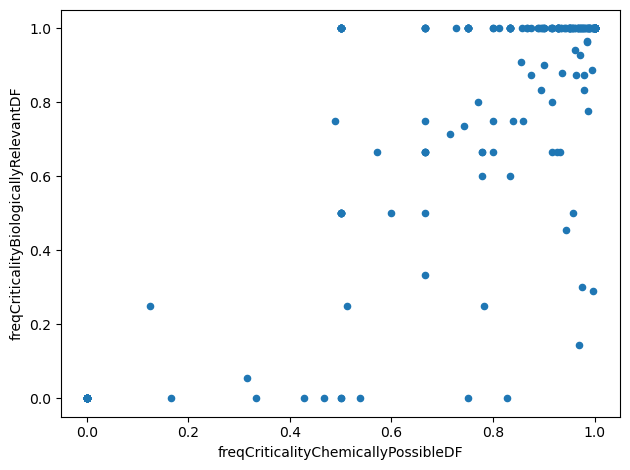

In [25]:
ax = dfMoleculesChemicallyPossibleBiologicallyRelevant.plot.scatter(x="freqCriticalityChemicallyPossibleDF", y="freqCriticalityBiologicallyRelevantDF")

plt.tight_layout()
plt.savefig("figures/reactome_version{}_hsa_chebiMoleculesCtriticalityFrequency_chemicallyPossible-biologicallyRelevant.svg".format(reactomeVersion), format="svg", bbox_inches="tight")

In [26]:
dfMoleculesChemicallyPossibleBiologicallyRelevant[(dfMoleculesChemicallyPossibleBiologicallyRelevant['freqCriticalityChemicallyPossibleDF'] >= 0.5) & (dfMoleculesChemicallyPossibleBiologicallyRelevant['freqCriticalityBiologicallyRelevantDF'] <= 0.5)]

,chebiID,countChemicallyPossible,countBiologicallyRelevant,moleculeChebiLabel,freqChemicallyPossible,freqBiologicallyRelevant,pValueBackgroundChemicallyPossible,adjPvalueBackgroundChemicallyPossible,pValueBackgroundBiologicallyRelevant,adjPvalueBackgroundBiologicallyRelevant,criticalityChemicallyPossible,criticalityBiologicallyRelevant,criticalityChemicallyPossibleDF,criticalityBiologicallyRelevantDF,freqCriticalityBiologicallyRelevantDF,freqCriticalityChemicallyPossibleDF
0,CHEBI:15377,351120,31,water,0.401743,0.011810,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.0,0.0,349928.0,9.0,0.290323,0.996605
1,CHEBI:15378,323202,130,hydron,0.369800,0.049524,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.0,0.0,315031.0,39.0,0.300000,0.974719
5,CHEBI:29101,14688,11,sodium(1+),0.016806,0.004190,5.242048e-10,7.312658e-08,1.000000e+00,1.000000e+00,0.0,0.0,13848.0,5.0,0.454545,0.942810
7,CHEBI:57783,10258,8,NADPH(4-),0.011737,0.003048,2.426223e-07,2.538436e-05,9.999998e-01,1.000000e+00,0.0,0.0,5254.0,2.0,0.250000,0.512186
8,CHEBI:58349,9000,7,NADP(3-),0.010298,0.002667,1.121694e-06,1.043176e-04,9.999989e-01,1.000000e+00,0.0,0.0,8730.0,1.0,0.142857,0.970000
18,CHEBI:17996,1840,4,chloride,0.002105,0.001524,1.980061e-01,1.000000e+00,8.019939e-01,8.126742e-01,0.0,0.0,1524.0,0.0,0.000000,0.828261
28,CHEBI:17544,522,12,hydrogencarbonate,0.000597,0.004571,9.999999e-01,1.000000e+00,9.714070e-08,7.009204e-07,0.0,0.0,408.0,3.0,0.250000,0.781609
111,CHEBI:57384,39,1,malonyl-CoA(5-),0.000045,0.000381,8.893061e-01,1.000000e+00,1.106939e-01,1.134036e-01,0.0,0.0,21.0,0.0,0.000000,0.538462
129,CHEBI:58053,24,2,IMP(2-),0.000027,0.000762,9.976182e-01,1.000000e+00,2.381785e-03,3.696906e-03,0.0,0.0,23.0,1.0,0.500000,0.958333
157,CHEBI:57502,15,12,nicotinate D-ribonucleotide(2-),0.000017,0.004571,1.000000e+00,1.000000e+00,2.371212e-28,1.174645e-26,0.0,0.0,9.0,6.0,0.500000,0.600000


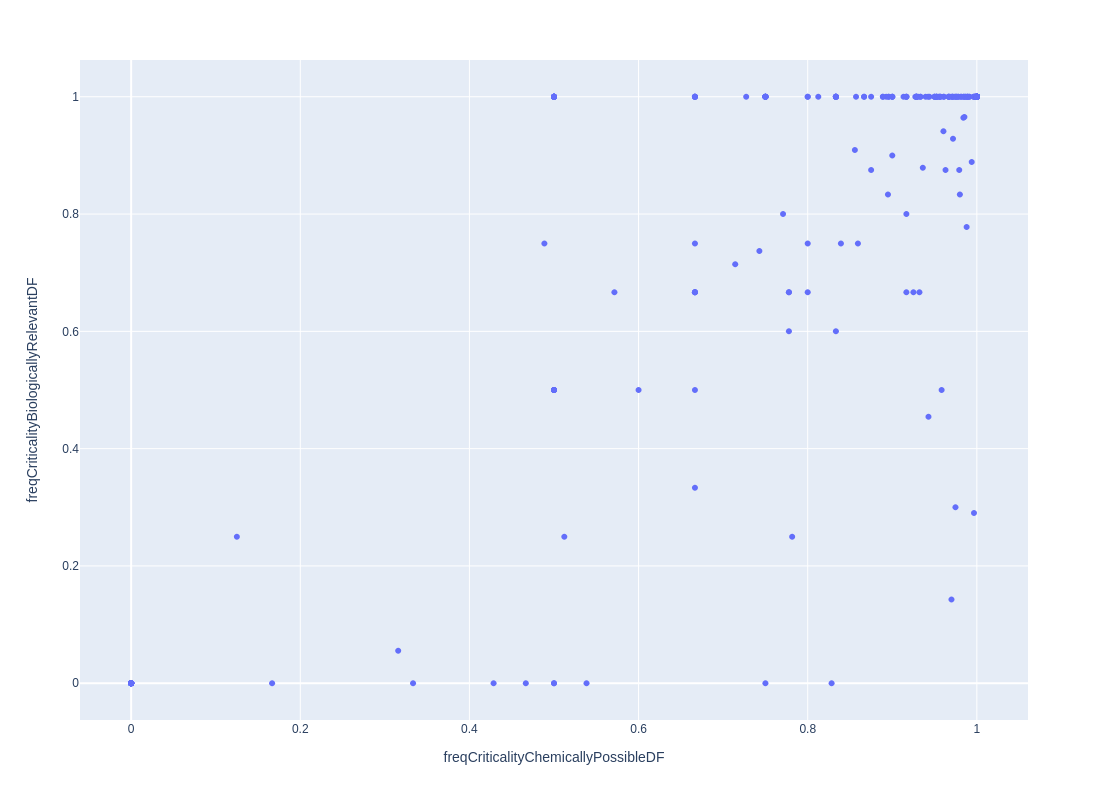

In [49]:
fig = px.scatter(dfMoleculesChemicallyPossibleBiologicallyRelevant, x="freqCriticalityChemicallyPossibleDF", y="freqCriticalityBiologicallyRelevantDF", hover_name="moleculeChebiLabel", hover_data=["countChemicallyPossible", "countBiologicallyRelevant"])
fig.update_layout(width=800)
fig.update_layout(height=800)
fig.show()

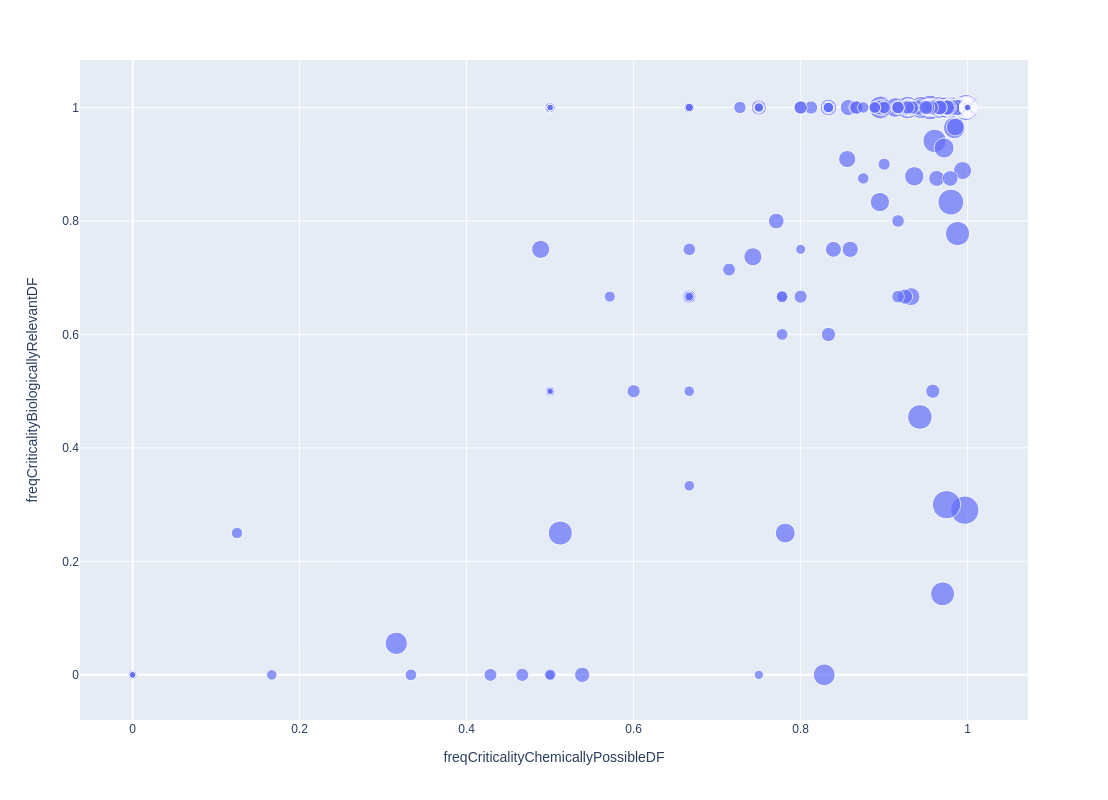

In [17]:
fig = px.scatter(dfMoleculesChemicallyPossibleBiologicallyRelevant, x="freqCriticalityChemicallyPossibleDF", y="freqCriticalityBiologicallyRelevantDF", hover_name="moleculeChebiLabel", hover_data=["countChemicallyPossible", "countBiologicallyRelevant"], size=np.log10(dfMoleculesChemicallyPossibleBiologicallyRelevant["countChemicallyPossible"]))
fig.update_layout(width=800)
fig.update_layout(height=800)
fig.show()

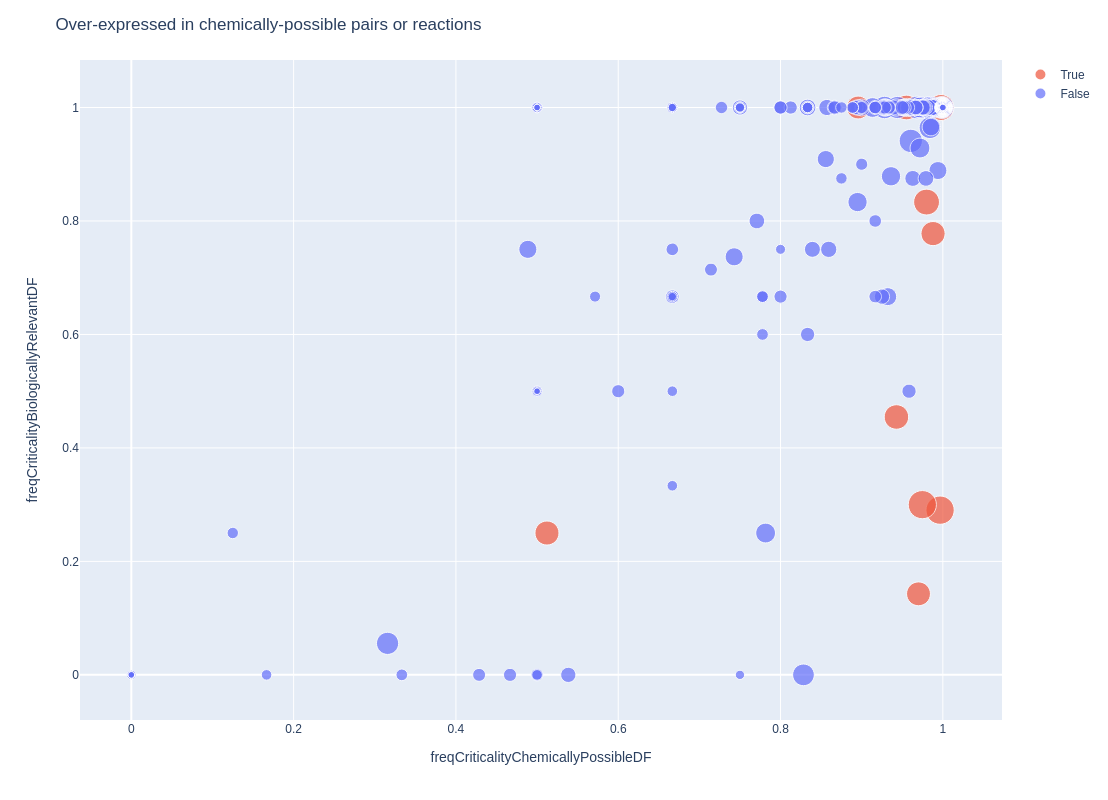

In [46]:
dfMoleculesChemicallyPossibleBiologicallyRelevant['isOverexpressedChemicallyPossible'] = dfMoleculesChemicallyPossibleBiologicallyRelevant['adjPvalueBackgroundChemicallyPossible'] <= 0.05

cmap = {True: px.colors.qualitative.Plotly[1], False: px.colors.qualitative.Plotly[0]}

fig = px.scatter(dfMoleculesChemicallyPossibleBiologicallyRelevant, x="freqCriticalityChemicallyPossibleDF", y="freqCriticalityBiologicallyRelevantDF", hover_name="moleculeChebiLabel", hover_data=["countChemicallyPossible", "countBiologicallyRelevant"], size=np.log10(dfMoleculesChemicallyPossibleBiologicallyRelevant["countChemicallyPossible"]), color="isOverexpressedChemicallyPossible", color_discrete_map = cmap)
fig.update_layout(width=800)
fig.update_layout(height=800)
fig.update_layout(title='Over-expressed in chemically-possible pairs or reactions')
#fig.update_layout(legend_title_text='is over-expressed')
fig.update_layout(legend_title_text='')

fig.show()

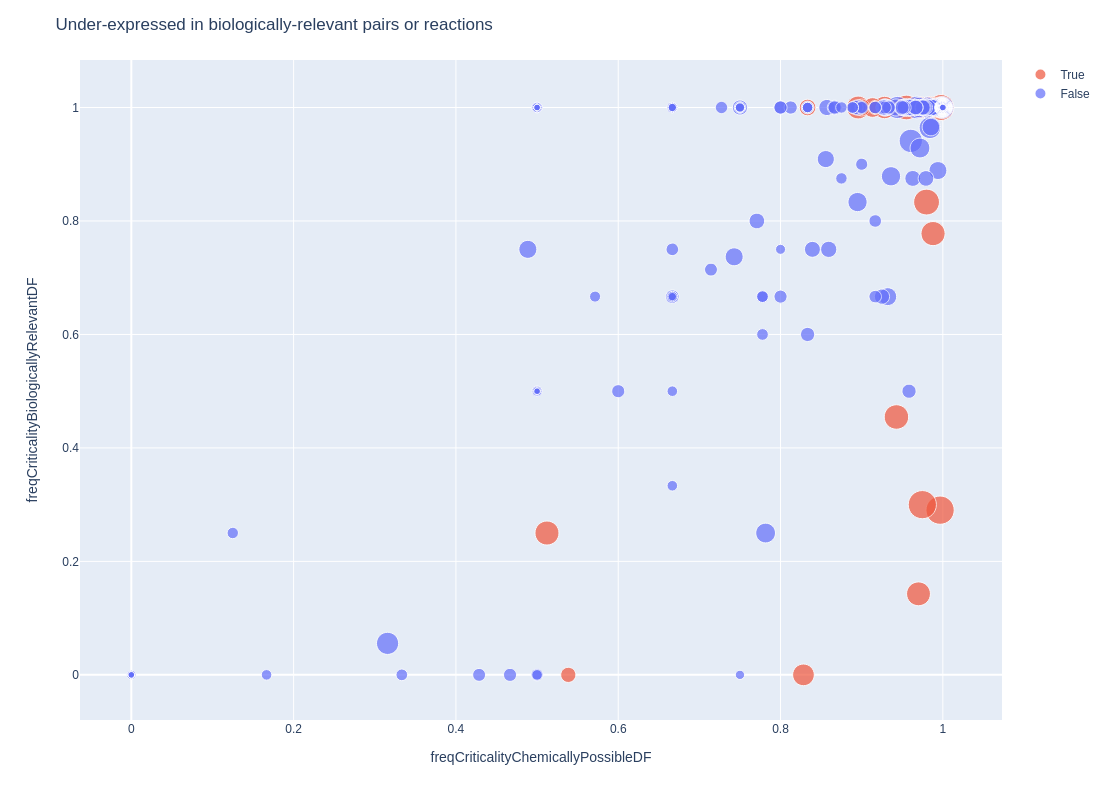

In [43]:
dfMoleculesChemicallyPossibleBiologicallyRelevant['isUnderexpressedBiologicallyRelevant'] = dfMoleculesChemicallyPossibleBiologicallyRelevant['adjPvalueBackgroundBiologicallyRelevant'] >= 0.05

cmap = {True: px.colors.qualitative.Plotly[1], False: px.colors.qualitative.Plotly[0]}

fig = px.scatter(dfMoleculesChemicallyPossibleBiologicallyRelevant, x="freqCriticalityChemicallyPossibleDF", y="freqCriticalityBiologicallyRelevantDF", hover_name="moleculeChebiLabel", hover_data=["countChemicallyPossible", "countBiologicallyRelevant"], size=np.log10(dfMoleculesChemicallyPossibleBiologicallyRelevant["countChemicallyPossible"]), color="isUnderexpressedBiologicallyRelevant", color_discrete_map = cmap)
fig.update_layout(width=800)
fig.update_layout(height=800)
fig.update_layout(title='Under-expressed in biologically-relevant pairs or reactions')
#fig.update_layout(legend_title_text='is over-expressed')
fig.update_layout(legend_title_text='')

fig.show()

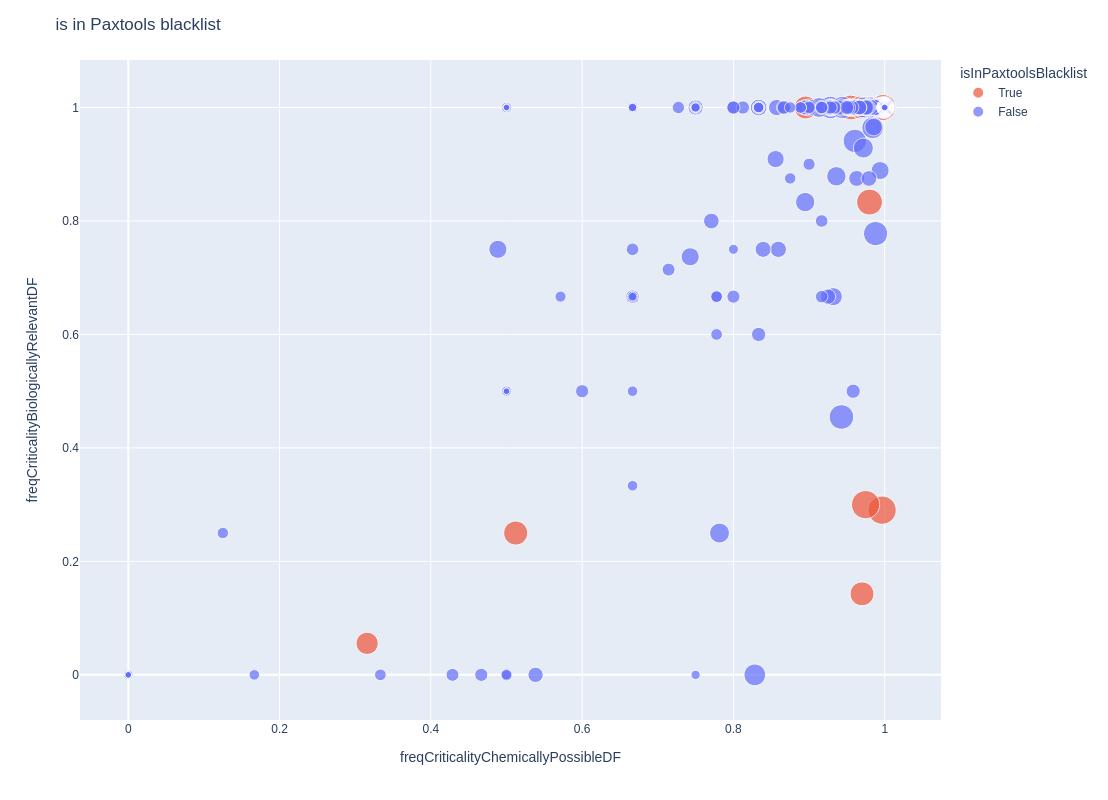

In [52]:

# blacklist.txt
#paxtoolsBlackList = ["CHEBI:13390", "CHEBI:16908", "CHEBI:4208", "CHEBI:58343", "CHEBI:17200", "CHEBI:57945", "CHEBI:17552", "CHEBI:16027", "CHEBI:456215", "CHEBI:46911", "CHEBI:15377", "CHEBI:15361", "CHEBI:15379", "CHEBI:30031", "CHEBI:57287", "CHEBI:25524", "CHEBI:57856", "CHEBI:16680", "CHEBI:58223", "CHEBI:16134", "CHEBI:16526", "CHEBI:18367", "CHEBI:13392", "CHEBI:29016", "CHEBI:15422", "CHEBI:17361", "CHEBI:29888", "CHEBI:32863", "CHEBI:16240", "CHEBI:17925", "CHEBI:35235", "CHEBI:57540", "CHEBI:58349", "CHEBI:15846", "CHEBI:57288", "CHEBI:58052", "CHEBI:57925", "CHEBI:13389", "CHEBI:16810", "CHEBI:57783", "CHEBI:17561", "CHEBI:30915", "CHEBI:15378", "CHEBI:32551", "CHEBI:35780", "CHEBI:16467", "CHEBI:15356", "CHEBI:17659", "CHEBI:58189", "CHEBI:58339", "CHEBI:16015", "CHEBI:16761", "CHEBI:60377", "CHEBI:32682", "CHEBI:15428", "CHEBI:17985", "CHEBI:15414", "CHEBI:45212", "CHEBI:456216", "CHEBI:37565", "CHEBI:16856", "CHEBI:30616", "CHEBI:59789", "CHEBI:17980", "CHEBI:68836", "CHEBI:15351", "CHEBI:16238", "CHEBI:15996", "CHEBI:16474", "CHEBI:29985", "CHEBI:15346", "CHEBI:18009", "CHEBI:51381"]
#
# blacklist-names.txt
#paxtoolsBlackList = ["CHEBI:13390", "CHEBI:16908", "CHEBI:57945", "CHEBI:17552", "CHEBI:15377", "CHEBI:15379", "CHEBI:25524", "CHEBI:24636", "CHEBI:16526", "CHEBI:29888", "CHEBI:18367", "CHEBI:13392", "CHEBI:77740", "CHEBI:15422", "CHEBI:28931", "CHEBI:57540", "CHEBI:58307", "CHEBI:58349", "CHEBI:17877", "CHEBI:15846", "CHEBI:57783", "CHEBI:15378", "CHEBI:58189", "CHEBI:35780", "CHEBI:18361", "CHEBI:35782", "CHEBI:16761", "CHEBI:26078", "CHEBI:43474", "CHEBI:25523", "CHEBI:456216", "CHEBI:37565", "CHEBI:30616", "CHEBI:68836", "CHEBI:15996", "CHEBI:16474", "CHEBI:18009"]
#
# blacklist.txt UNION blacklist-names.txt
paxtoolsBlackList = ["CHEBI:13390", "CHEBI:16908", "CHEBI:4208", "CHEBI:17200", "CHEBI:57945", "CHEBI:16027", "CHEBI:456215", "CHEBI:15361", "CHEBI:30031", "CHEBI:57287", "CHEBI:58223", "CHEBI:16134", "CHEBI:16526", "CHEBI:35235", "CHEBI:13392", "CHEBI:28931", "CHEBI:58349", "CHEBI:17877", "CHEBI:15846", "CHEBI:57925", "CHEBI:16810", "CHEBI:57783", "CHEBI:30915", "CHEBI:15378", "CHEBI:60377", "CHEBI:17659", "CHEBI:15356", "CHEBI:58339", "CHEBI:35782", "CHEBI:16015", "CHEBI:16761", "CHEBI:26078", "CHEBI:15428", "CHEBI:37565", "CHEBI:16856", "CHEBI:30616", "CHEBI:59789", "CHEBI:15351", "CHEBI:16238", "CHEBI:16474", "CHEBI:18009", "CHEBI:51381", "CHEBI:58343", "CHEBI:17552", "CHEBI:46911", "CHEBI:15377", "CHEBI:57856", "CHEBI:15379", "CHEBI:25524", "CHEBI:16680", "CHEBI:24636", "CHEBI:18367", "CHEBI:29888", "CHEBI:32863", "CHEBI:29016", "CHEBI:77740", "CHEBI:15422", "CHEBI:17361", "CHEBI:57540", "CHEBI:16240", "CHEBI:17925", "CHEBI:58307", "CHEBI:57288", "CHEBI:58052", "CHEBI:13389", "CHEBI:17561", "CHEBI:58189", "CHEBI:32551", "CHEBI:35780", "CHEBI:16467", "CHEBI:18361", "CHEBI:32682", "CHEBI:43474", "CHEBI:25523", "CHEBI:17985", "CHEBI:15414", "CHEBI:45212", "CHEBI:456216", "CHEBI:17980", "CHEBI:68836", "CHEBI:29985", "CHEBI:15996", "CHEBI:15346"]


#print(dfMoleculesChemicallyPossibleBiologicallyRelevant[dfMoleculesChemicallyPossibleBiologicallyRelevant["chebiID"].isin(paxtoolsBlackList)])
dfMoleculesChemicallyPossibleBiologicallyRelevant["isInPaxtoolsBlacklist"] = dfMoleculesChemicallyPossibleBiologicallyRelevant["chebiID"].isin(paxtoolsBlackList)

cmap = {True: px.colors.qualitative.Plotly[1], False: px.colors.qualitative.Plotly[0]}

fig = px.scatter(dfMoleculesChemicallyPossibleBiologicallyRelevant, x="freqCriticalityChemicallyPossibleDF", y="freqCriticalityBiologicallyRelevantDF", hover_name="moleculeChebiLabel", hover_data=["countChemicallyPossible", "countBiologicallyRelevant"], size=np.log10(dfMoleculesChemicallyPossibleBiologicallyRelevant["countChemicallyPossible"]), color="isInPaxtoolsBlacklist", color_discrete_map = cmap)
fig.update_layout(width=800)
fig.update_layout(height=800)
fig.update_layout(title='is in Paxtools blacklist')
fig.show()